# Chapter 2 — Applied validation on realistic feature distributions

Chapter 0 defines the Bayesian corruption model, and Chapter 1 evaluates it under controlled simulation. The simulation results show that good observation-level localisation does not necessarily imply recovery of the underlying corruption mechanism, and that recovery depends on the amount and structure of the available corruption information.

This chapter tests the same framework using realistic covariate distributions from BRFSS diabetes and UCI credit default.

The analysis is **semi-synthetic**: the recorded labels are treated as reference labels, known one-sided $1\to0$ corruption is injected into the training data only, and the clean test set is left unchanged. This means the true injected corruption indicators are known and can be used to evaluate recovery and localisation.

The chapter considers the three dissertation research questions:

- **RQ1:** recovery of the latent response relationship and corruption parameters;
- **RQ2:** recovery and localisation of the corruption region;
- **RQ3:** observation-level posterior corruption probabilities.

Predictive robustness is reported separately, since a small change in clean-test AUC does not imply successful recovery of the corruption mechanism.

BRFSS is the primary application and Credit provides a second-domain check. The main Bayesian fits use prespecified halfspace directions. A general-boundary BRFSS fit is also included as a stress test. Posterior mechanism-recovery results are interpreted only when the diagnostic gate is passed.

> **High-replication version:** the BRFSS predictive-sensitivity sweep uses 20 independent corruption replicates per value of $q$. The main BRFSS and Credit Bayesian fits are unchanged. Outputs from this version are written under `high_replication/chapter2/`.

## 0. Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    brier_score_loss,
    log_loss,
)

from cleanlab.rank import get_label_quality_scores

try:
    from cmdstanpy import CmdStanModel
    STAN_AVAILABLE = True
except Exception as exc:
    STAN_AVAILABLE = False
    print("CmdStanPy unavailable:", exc)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Reproducibility
SEED = 42
KAPPA = 5.0
# Main applied corruption setting
Q_APPLIED = 0.35
BAYES_N = 6000

# Diagnostic thresholds used throughout the dissertation
RHAT_MAX = 1.05
ESS_MIN = 100

DATA_DIR = Path("data")
BRFSS_PATH = DATA_DIR / "diabetes_binary_health_indicators_BRFSS2015.csv"
CREDIT_PATH = DATA_DIR / "UCI_Credit_Card.csv"

AXIS_STAN = None  
GENERAL_STAN = None  

# Keep regenerated outputs separate from the original dissertation files.
HIGHREP_ROOT = Path("high_replication") / "chapter2"
FIG_DIR = HIGHREP_ROOT / "figures"
RESULT_DIR = HIGHREP_ROOT / "results"
STAN_DIR = HIGHREP_ROOT / "stan"

for folder in [FIG_DIR, RESULT_DIR, STAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

AXIS_STAN = STAN_DIR / "corruption_model_axis_FINAL.stan"
GENERAL_STAN = STAN_DIR / "corruption_model_general_FINAL.stan"

# Check that the expected input files are available.
for p in [BRFSS_PATH, CREDIT_PATH]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

print("Safe Chapter 2 figure directory:", FIG_DIR.resolve())
print("Safe Chapter 2 result directory:", RESULT_DIR.resolve())

data/diabetes_binary_health_indicators_BRFSS2015.csv: OK
data/UCI_Credit_Card.csv: OK
Safe Chapter 2 figure directory: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/figures
Safe Chapter 2 result directory: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/results


### Embedded Stan models

The axis-supplied and general-boundary Stan models from Chapter 0 are written here again so this notebook can run independently. They are saved in the high-replication folder to avoid overwriting the original files.

In [2]:
stan_code = r'''
/*
  Structured Label Corruption Model v6 — Soft Boundary, One-Sided (1 -> 0)
  ========================================================================
  Corruption mechanism (underdiagnosis): a true positive inside the
  region is recorded as negative with probability q. Negatives are
  never flipped. Changes from v5:

  1. Direction: likelihood matches the 1->0 operator used in
     Chapters 1 and 2:
        P(y = 1 | x) = (1 - q r) p
        P(y = 0 | x) = (1 - p) + q r p
     with p = inv_logit(beta0 + x.beta), r = inv_logit(kappa (x_b - c)).
     Under this mechanism z_i = 1 is only possible when y_i = 0.
  2. Intercept beta0 added (the DGP has one; omitting it biases
     beta, c and q).
  3. Corruption terms computed on the log scale via log_inv_logit
     for numerical stability far from the boundary.
  4. c prior centre AND sd passed as data — the centre must not be
     set to the simulation truth (that would be circular).
  5. log_lik in generated quantities for LOO/WAIC.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;              // boundary sharpness (fixed; sensitivity in Sec. 8)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta  ~ normal(0, 1);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        // observed positive: must be a clean true positive
        target += log1m_exp(log_qr) + log_p;
      } else {
        // observed negative: true negative OR hidden (corrupted) positive
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;   // P(z_i = 1 | y_i, theta); zero by construction when y_i = 1
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(AXIS_STAN, 'w') as f:
    f.write(stan_code)
print(f'Axis Stan model written safely to {AXIS_STAN}')


Axis Stan model written safely to high_replication/chapter2/stan/corruption_model_axis_FINAL.stan


In [3]:
stan_code_v7 = r'''
/*
  Structured Label Corruption Model v7 — General Hyperplane Boundary
  ===================================================================
  Extension of v6: the corruption boundary is a general hyperplane
      R = { x : alpha . x > c },   ||alpha|| = 1,
  with the full normal vector alpha estimated jointly with (beta0, beta, c, q).
  This implements the supervisor's specification with alpha in R^p, rather
  than fixing the boundary axis as domain knowledge.

  Identifiability notes:
  - ||alpha|| = 1 fixes the scale non-identifiability of (alpha, c).
    Implemented via the normalized-vector trick: alpha_raw ~ normal(0, 1),
    alpha = alpha_raw / ||alpha_raw||. With an isotropic Gaussian prior
    on alpha_raw this induces no preferred orientation.
  - There is no sign/reflection ambiguity for the region itself:
    {x : alpha.x > c} and {x : -alpha.x > -c} are complementary halfspaces,
    not the same set. These constraints remove parameterisation ambiguity;
    practical recovery from finite data is assessed empirically below.
  - Everything else (one-sided 1->0 likelihood, soft boundary, marginalised
    latents, closed-form z_prob, log_lik) matches v6.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  real kappa;              // soft-boundary steepness (fixed)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  vector[p] alpha_raw;     // unnormalised boundary normal
  real c;
  real<lower=0, upper=1> q;
}

transformed parameters {
  vector[p] alpha = alpha_raw / norm2(alpha_raw);
}

model {
  beta0     ~ normal(0, 2);
  beta      ~ normal(0, 1);
  alpha_raw ~ normal(0, 1);      // induces uniform prior on the unit sphere
  c         ~ normal(c_prior_mean, c_prior_sd);
  q         ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(GENERAL_STAN, 'w') as f:
    f.write(stan_code_v7)
print(f'General Stan model written safely to {GENERAL_STAN}')


General Stan model written safely to high_replication/chapter2/stan/corruption_model_general_FINAL.stan


In [4]:
# Shared dissertation plotting conventions
# These settings only standardise typography and output quality.
# They do not change the data, fitted models, estimands or figure filenames.

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "errorbar.capsize": 3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})


## 1. Shared helpers

In [5]:
# Only interpret recovery results for fits that pass the diagnostic gate.
# Inject one-sided 1 -> 0 corruption inside the specified region.
def corrupt_one_sided(y_true, region, q, rng):
    y_true = np.asarray(y_true, dtype=int)
    region = np.asarray(region, dtype=bool)
    eligible = (y_true == 1) & region
    flips = eligible & (rng.random(len(y_true)) < q)
    y_obs = y_true.copy()
    y_obs[flips] = 0
    return y_obs, flips

# Check that the injected corruption follows the intended mechanism.
def audit_corruption(y_true, y_obs, region, q, label=""):
    changed = y_true != y_obs
    flips_10 = ((y_true == 1) & (y_obs == 0)).sum()
    flips_01 = ((y_true == 0) & (y_obs == 1)).sum()
    outside = (changed & ~region).sum()
    eligible = ((y_true == 1) & region).sum()

    # Fail immediately if anything other than the intended 1 -> 0 regional corruption occurred.
    assert flips_01 == 0
    assert outside == 0

    return {
        "dataset": label,
        "n": len(y_true),
        "q": q,
        "region_share": region.mean(),
        "eligible_positives": eligible,
        "n_corrupted": changed.sum(),
        "effective_flip_rate": changed.mean(),
        "flips_1_to_0": flips_10,
        "flips_0_to_1": flips_01,
        "corruptions_outside_region": outside,
    }

# Fit the standard logistic-regression predictive baseline.
def fit_lr(X_train, y_train, X_test, y_test, seed=SEED):
    # Class-weighted logistic regression used for the predictive baseline.
    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=seed,
    )
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    return {
        "model": model,
        "auc": roc_auc_score(y_test, prob),
        "f1": f1_score(y_test, pred),
        "prob": prob,
    }

# Precision among the k highest-scoring observations.
def precision_at_k(truth, score, k):
    truth = np.asarray(truth, dtype=bool)
    score = np.asarray(score, dtype=float)
    if k <= 0:
        return np.nan
    k = min(int(k), len(score))
    top = np.argsort(score)[::-1][:k]
    return truth[top].mean()

# Evaluate localisation among observed negatives only.
def ranking_metrics(y_obs, flips, score):
    y_obs = np.asarray(y_obs, dtype=int)
    flips = np.asarray(flips, dtype=bool)
    score = np.asarray(score, dtype=float)

    # Only observed negatives are candidates under one-sided 1 -> 0 corruption.
    candidate = y_obs == 0
    y_rank = flips[candidate].astype(int)
    s_rank = score[candidate]
    k = int(flips.sum())

    auc = np.nan if y_rank.min() == y_rank.max() else roc_auc_score(y_rank, s_rank)

    return {
        "n_candidates": int(candidate.sum()),
        "n_corrupted": k,
        "ranked_auc": auc,
        "precision_at_k": precision_at_k(y_rank, s_rank, k),
    }

# Get out-of-fold Cleanlab scores for the same observation-ranking task.
def cleanlab_scores(X, y_obs, seed=SEED, folds=3):
    base = LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=seed,
    )
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    pred_probs = cross_val_predict(
        base, X, y_obs.astype(int),
        cv=cv, method="predict_proba", n_jobs=-1
    )
    quality = get_label_quality_scores(
        labels=y_obs.astype(int),
        pred_probs=pred_probs
    )
    return 1.0 - quality # Cleanlab returns label quality, so invert it to get an error score.

# Summarise the sampler diagnostics used for the dissertation gate.
def core_sampler_diagnostics(fit):
    s = fit.summary()
    # Apply the diagnostic gate to the main model parameters rather than generated quantities.
    mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
        | s.index.str.startswith("alpha[")
    )
    core = s.loc[mask].copy()

    mv = fit.method_variables()
    divergences = int(
        np.asarray(mv.get("divergent__", np.array([0]))).sum()
    )

    treedepth = np.asarray(
        mv.get("treedepth__", np.array([]))
    )
    # Match the max tree depth used in the Stan fits.
    max_treedepth_hits = (
        int((treedepth >= 12).sum())
        if treedepth.size > 0
        else 0
    )

    max_rhat = float(
        core["R_hat"].replace([np.inf, -np.inf], np.nan).max()
    )
    min_ess = float(
        core["ESS_bulk"].replace([np.inf, -np.inf], np.nan).min()
    )

    # A fit passes only if all four diagnostic criteria are satisfied.
    converged = (
        divergences == 0
        and max_treedepth_hits == 0
        and max_rhat <= RHAT_MAX
        and min_ess >= ESS_MIN
    )

    return {
        "divergences": divergences,
        "max_treedepth_hits": max_treedepth_hits,
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess,
        "converged": converged,
    }, core

# Take a reproducible sample while preserving label and region strata.
def stratified_application_sample(X, y, region, n, seed):
    # Preserve the reference-label/region composition in the 6,000-row sample.
    strata = y.astype(str) + "_" + region.astype(int).astype(str)
    idx = np.arange(len(y))
    if n >= len(y):
        return idx
    chosen, _ = train_test_split(
        idx,
        train_size=n,
        random_state=seed,
        stratify=strata,
    )
    return np.sort(chosen)

# Logistic sigmoid used for the soft region-membership calculation.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Compare the reduced logistic response model with a more flexible model before corruption.
def pre_corruption_response_check(
    X_train,
    y_train,
    X_test,
    y_test,
    dataset_label,
    file_stem,
    seed=SEED,
    n_bins=10,
):
    """
    Compare the logistic response model with a more flexible model before
    corruption is added.
    """

    # Use the unweighted version here to match the Bayesian response model.
    logistic = LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=seed,
    )
    logistic.fit(X_train, y_train)
    p_logistic = logistic.predict_proba(X_test)[:, 1]

    # Flexible comparison to check for signal the logistic model may be missing.
    flexible = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=seed,
    )
    flexible.fit(X_train, y_train)
    p_flexible = flexible.predict_proba(X_test)[:, 1]

    rows = []
    curves = {}

    for model_name, prob in [
        ("Logistic", p_logistic),
        ("Flexible HGB", p_flexible),
    ]:
    # Use equal-count probability bins for the calibration summary.
        frac_pos, mean_pred = calibration_curve(
            y_test,
            prob,
            n_bins=n_bins,
            strategy="quantile",
        )

        rows.append({
            "dataset": dataset_label,
            "model": model_name,
            "auc": roc_auc_score(y_test, prob),
            "brier": brier_score_loss(y_test, prob),
            "log_loss": log_loss(y_test, prob),
            # Descriptive average gap between observed and predicted rates across bins.
            "mean_abs_calibration_bin_gap": float(
                np.mean(np.abs(frac_pos - mean_pred))
            ),
        })

        curves[model_name] = {
            "mean_pred": mean_pred,
            "frac_pos": frac_pos,
        }

    metrics = pd.DataFrame(rows)

    metrics.to_csv(
        RESULT_DIR / f"{file_stem}_pre_corruption_response_check.csv",
        index=False,
    )

    display(metrics)

    logistic_auc = float(
        metrics.loc[metrics["model"] == "Logistic", "auc"].iloc[0]
    )
    flexible_auc = float(
        metrics.loc[metrics["model"] == "Flexible HGB", "auc"].iloc[0]
    )

    print(
        f"{dataset_label}: flexible-minus-logistic held-out AUC = "
        f"{flexible_auc - logistic_auc:+.4f}"
    )
    print(
        "Interpret this as a response-specification diagnostic, not as a "
        "formal goodness-of-fit test."
    )

    fig, ax = plt.subplots(figsize=(6.6, 5.0))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Perfect calibration",
    )

    for model_name in ["Logistic", "Flexible HGB"]:
        ax.plot(
            curves[model_name]["mean_pred"],
            curves[model_name]["frac_pos"],
            marker="o",
            label=model_name,
        )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive fraction")
    ax.set_title(
        f"{dataset_label} — pre-corruption response-model check"
    )
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / f"{file_stem}_pre_corruption_response_check.pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        FIG_DIR / f"{file_stem}_pre_corruption_response_check.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "metrics": metrics,
        "logistic_model": logistic,
        "flexible_model": flexible,
        "logistic_prob": p_logistic,
        "flexible_prob": p_flexible,
    }


# 2. BRFSS primary application

The BRFSS analysis uses the recorded diabetes label as the reference outcome and then injects a known additional one-sided corruption mechanism after the train/test split. The purpose is not to estimate naturally occurring underdiagnosis. It is to test whether the proposed framework can recover a known corruption mechanism on realistic health covariates.

## 2.1 Data, split and clean ceiling

In [7]:
# Load the BRFSS data and define the recorded diabetes outcome.
if not BRFSS_PATH.exists():
    raise FileNotFoundError(f"Missing {BRFSS_PATH}")

brfss = pd.read_csv(BRFSS_PATH)

TARGET_B = "Diabetes_binary"
FEATURES_B = [
    "HighBP","HighChol","CholCheck","BMI","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost","GenHlth",
    "MentHlth","PhysHlth","DiffWalk","Sex","Age","Education","Income",
]

Xb_raw = brfss[FEATURES_B].copy()
yb = brfss[TARGET_B].to_numpy(dtype=int)

# Stratified split keeps the recorded diabetes prevalence similar in train and test.
Xb_train_raw, Xb_test_raw, yb_train, yb_test = train_test_split(
    Xb_raw, yb,
    test_size=0.20,
    stratify=yb,
    random_state=SEED
)

Xb_train_raw = Xb_train_raw.reset_index(drop=True)
Xb_test_raw = Xb_test_raw.reset_index(drop=True)

# Standardise using the training data only.
scaler_b = StandardScaler()
Xb_train_z_full = scaler_b.fit_transform(Xb_train_raw)
Xb_test_z_full = scaler_b.transform(Xb_test_raw)

# Clean-data predictive baseline before any corruption is injected.
clean_b = fit_lr(
    Xb_train_z_full, yb_train,
    Xb_test_z_full, yb_test
)

print(f"BRFSS rows: {len(brfss):,}")
print(f"Recorded diabetes prevalence: {yb.mean():.3%}")
print(f"Train/test: {len(yb_train):,} / {len(yb_test):,}")
print(f"Clean LR AUC: {clean_b['auc']:.4f}")
print(f"Clean LR F1:  {clean_b['f1']:.4f}")
print(f"BRFSS predictors: {len(FEATURES_B)}")

summary_brfss = pd.DataFrame({
    "Metric": [
        "Rows",
        "Recorded diabetes prevalence",
        "Training observations",
        "Test observations",
        "Test prevalence",
        "Predictors",
        "Clean LR AUC",
        "Clean LR F1",
    ],
    "Value": [
        f"{len(brfss):,}",
        f"{yb.mean():.3%}",
        f"{len(yb_train):,}",
        f"{len(yb_test):,}",
        f"{yb_test.mean():.3%}",
        len(FEATURES_B),
        f"{clean_b['auc']:.4f}",
        f"{clean_b['f1']:.4f}",
    ],
})

display(summary_brfss.style.hide(axis="index"))

BRFSS rows: 253,680
Recorded diabetes prevalence: 13.933%
Train/test: 202,944 / 50,736
Clean LR AUC: 0.8196
Clean LR F1:  0.4413
BRFSS predictors: 21


Metric,Value
Rows,"253,680"
Recorded diabetes prevalence,13.933%
Training observations,"202,944"
Test observations,"50,736"
Test prevalence,13.933%
Predictors,21
Clean LR AUC,0.8196
Clean LR F1,0.4413


## 2.2 Model-aligned susceptible region

The primary Bayesian application uses a prespecified halfspace based on BMI and general health.

A prespecified score is defined by

$$
s_i = \frac{z(\mathrm{BMI}_i) + z(\mathrm{GenHlth}_i)}{\sqrt{2}}.
$$

The threshold is the 90th percentile of the training score, chosen using the covariates only so that approximately 10% of the training sample lies inside the susceptible region. Labels are not used to choose the threshold.

The orthogonal contrast is retained in the response-model matrix, allowing the latent response to vary both along and orthogonal to the corruption-boundary direction.

c_true,region_n,region_share,recorded_positive_rate_overall,recorded_positive_rate_inside,recorded_positive_rate_outside,eligible_positives
1.461,19638,9.68%,13.93%,39.75%,11.17%,7807


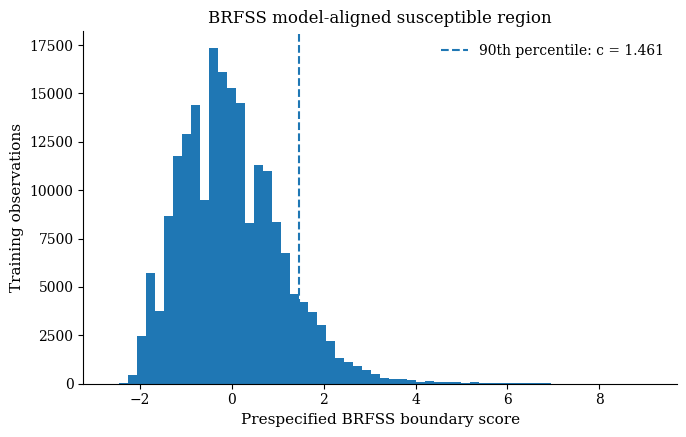

In [8]:
# Build the reduced BRFSS model matrix used in the Bayesian fit.
def make_brfss_model_matrix(train_raw, test_raw):
    core = ["BMI", "GenHlth", "HighBP", "DiffWalk", "Age", "Income"]

    # Standardise using the training data only.
    scaler = StandardScaler()
    Ztr = scaler.fit_transform(train_raw[core])
    Zte = scaler.transform(test_raw[core])

    i_bmi = core.index("BMI")
    i_gen = core.index("GenHlth")

    # Boundary score and orthogonal BMI/GenHlth contrast.
    score_tr = (Ztr[:, i_bmi] + Ztr[:, i_gen]) / np.sqrt(2.0)
    contrast_tr = (Ztr[:, i_bmi] - Ztr[:, i_gen]) / np.sqrt(2.0)

    score_te = (Zte[:, i_bmi] + Zte[:, i_gen]) / np.sqrt(2.0)
    contrast_te = (Zte[:, i_bmi] - Zte[:, i_gen]) / np.sqrt(2.0)

    others = ["HighBP", "DiffWalk", "Age", "Income"]
    idx = [core.index(c) for c in others]

    Xtr = np.column_stack([score_tr, contrast_tr, Ztr[:, idx]])
    Xte = np.column_stack([score_te, contrast_te, Zte[:, idx]])

    feature_names = [
        "boundary_score",
        "BMI_minus_GenHlth",
        *others,
    ]

    return Xtr, Xte, feature_names, scaler


Xb_model, Xb_model_test, BRFSS_MODEL_FEATURES, brfss_model_scaler = (
    make_brfss_model_matrix(
        Xb_train_raw,
        Xb_test_raw,
    )
)

# Use the 90th percentile of the training score only.
C_B_TRUE = float(np.quantile(Xb_model[:, 0], 0.90))
region_b = Xb_model[:, 0] > C_B_TRUE

region_summary_b = pd.DataFrame([{
    "c_true": C_B_TRUE,
    "region_n": int(region_b.sum()),
    "region_share": region_b.mean(),
    "recorded_positive_rate_overall": yb_train.mean(),
    "recorded_positive_rate_inside": yb_train[region_b].mean(),
    "recorded_positive_rate_outside": yb_train[~region_b].mean(),
    "eligible_positives": int(((yb_train == 1) & region_b).sum()),
}])

display(
    region_summary_b.style
    .format({
        "c_true": "{:.3f}",
        "region_share": "{:.2%}",
        "recorded_positive_rate_overall": "{:.2%}",
        "recorded_positive_rate_inside": "{:.2%}",
        "recorded_positive_rate_outside": "{:.2%}",
    })
    .hide(axis="index")
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    Xb_model[:, 0],
    bins=60,
)

ax.axvline(
    C_B_TRUE,
    linestyle="--",
    linewidth=1.5,
    label=f"90th percentile: c = {C_B_TRUE:.3f}",
)

ax.set_xlabel("Prespecified BRFSS boundary score")
ax.set_ylabel("Training observations")
ax.set_title("BRFSS model-aligned susceptible region")
ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_brfss_susceptible_region.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "fig_ch2_brfss_susceptible_region.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 2.2a Pre-corruption response-model check

Before any labels are corrupted, the logistic response specification is checked on the **same reduced model matrix used by the Bayesian response component**.

Held-out AUC, Brier score, log loss and a descriptive calibration-bin gap are reported for the logistic model, alongside an untuned histogram gradient-boosting classifier as a flexible comparator.

The purpose is diagnostic rather than a formal goodness-of-fit test. A clear advantage for the flexible model would provide evidence of response-model mismatch that should be considered when interpreting later mechanism recovery.

,dataset,model,auc,brier,log_loss,mean_abs_calibration_bin_gap
0,BRFSS,Logistic,0.807745,0.101971,0.329434,0.015274
1,BRFSS,Flexible HGB,0.814439,0.099645,0.322291,0.003770


BRFSS: flexible-minus-logistic held-out AUC = +0.0067
Interpret this as a response-specification diagnostic, not as a formal goodness-of-fit test.


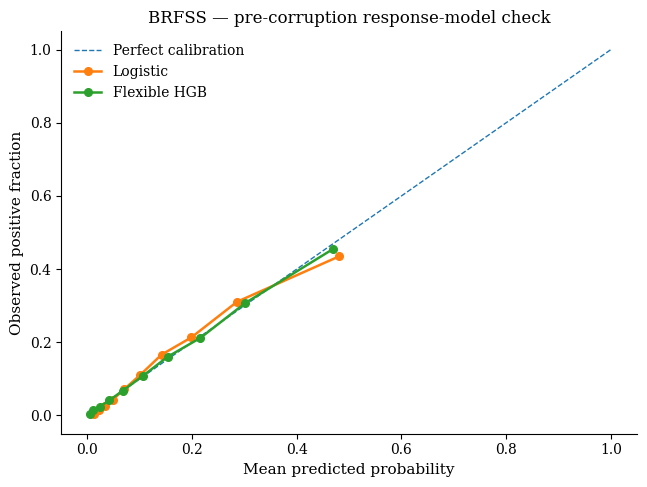

In [9]:
# Run the pre-corruption response-model check on the reduced BRFSS matrix.
brfss_pre_corruption_check = pre_corruption_response_check(
    X_train=Xb_model,
    y_train=yb_train,
    X_test=Xb_model_test,
    y_test=yb_test,
    dataset_label="BRFSS",
    file_stem="highrep_brfss",
    seed=SEED,
)

## 2.3 Predictive robustness on the full training set

The within-region corruption probability is varied over

$$
q \in \{0.10, 0.20, 0.35, 0.50, 0.70\}.
$$

The clean test set is left unchanged. This analysis measures how clean-test discrimination changes as the localised corruption mechanism becomes stronger.

The realised number of corrupted labels and the effective global flip rate are reported alongside the nominal value of $q$, because only reference positives inside the susceptible region are eligible to be flipped.

This is a predictive-robustness analysis rather than a direct test of mechanism recovery.

q,n_corrupted_mean,effective_flip_rate_mean,auc_mean,auc_sd,auc_drop_mean,auc_drop_sd,f1_mean
0.10,774.9,0.382%,0.81939,0.00002,0.00024,0.00002,0.4411
0.20,1569.7,0.773%,0.81897,0.00003,0.00066,0.00003,0.4398
0.35,2720.8,1.341%,0.81799,0.00006,0.00164,0.00006,0.4388
0.50,3900.2,1.922%,0.81625,0.00011,0.00338,0.00011,0.4363
0.70,5458.4,2.690%,0.81219,0.00014,0.00744,0.00014,0.4309


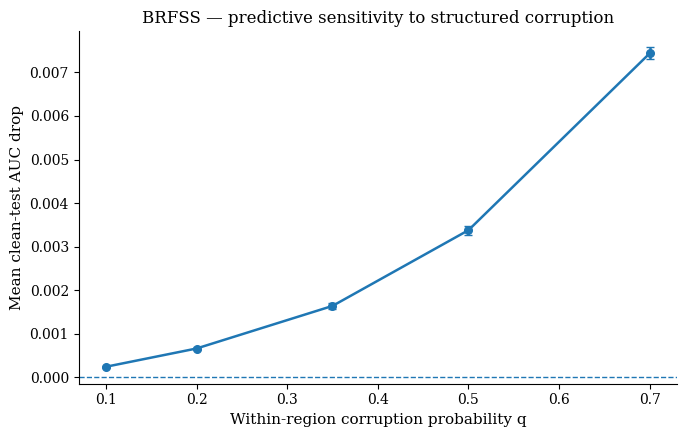

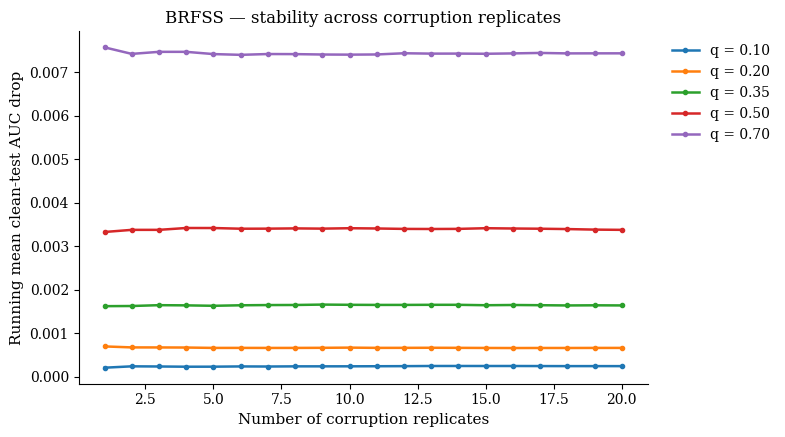

In [11]:
# Run 20 independent corruption replicates for each q value.
Q_VALUES = [0.10, 0.20, 0.35, 0.50, 0.70]
N_PRED_REPS = 20

predictive_rows = []

for q in Q_VALUES:
    for rep in range(N_PRED_REPS):
        rng = np.random.default_rng(
            SEED + 1000 + int(q * 1000) + rep
        )

        y_obs, flips = corrupt_one_sided(
            yb_train,
            region_b,
            q,
            rng,
        )

        naive = fit_lr(
            Xb_train_z_full,
            y_obs,
            Xb_test_z_full,
            yb_test,
            seed=SEED + rep,
        )

        predictive_rows.append({
            "q": q,
            "rep": rep,
            "n_corrupted": int(flips.sum()),
            "effective_flip_rate": flips.mean(),
            "auc": naive["auc"],
            "auc_drop": clean_b["auc"] - naive["auc"],
            "f1": naive["f1"],
        })

predictive_b = pd.DataFrame(predictive_rows)

# Summarise the mean and between-replicate variation at each corruption level.
predictive_b_summary = (
    predictive_b
    .groupby("q", as_index=False)
    .agg(
        n_corrupted_mean=("n_corrupted", "mean"),
        effective_flip_rate_mean=("effective_flip_rate", "mean"),
        auc_mean=("auc", "mean"),
        auc_sd=("auc", "std"),
        auc_drop_mean=("auc_drop", "mean"),
        auc_drop_sd=("auc_drop", "std"),
        f1_mean=("f1", "mean"),
    )
)

display(
    predictive_b_summary.style
    .format({
        "q": "{:.2f}",
        "n_corrupted_mean": "{:.1f}",
        "effective_flip_rate_mean": "{:.3%}",
        "auc_mean": "{:.5f}",
        "auc_sd": "{:.5f}",
        "auc_drop_mean": "{:.5f}",
        "auc_drop_sd": "{:.5f}",
        "f1_mean": "{:.4f}",
    })
    .hide(axis="index")
)

# Save replicate-level and summary results.
predictive_b.to_csv(
    RESULT_DIR / "highrep_brfss_predictive_sensitivity_replicates.csv",
    index=False,
)

predictive_b_summary.to_csv(
    RESULT_DIR / "highrep_brfss_predictive_sensitivity_summary.csv",
    index=False,
)

# Main predictive-sensitivity figure.
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    predictive_b_summary["q"],
    predictive_b_summary["auc_drop_mean"],
    yerr=predictive_b_summary["auc_drop_sd"],
    marker="o",
    capsize=3,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Within-region corruption probability q")
ax.set_ylabel("Mean clean-test AUC drop")
ax.set_title("BRFSS — predictive sensitivity to structured corruption")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_sensitivity.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Check that the replicate means have stabilised.
running = predictive_b.copy()

running["running_auc_drop"] = (
    running
    .groupby("q")["auc_drop"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4.5))

for q in Q_VALUES:
    subset = running[running["q"] == q]

    ax.plot(
        subset["rep"] + 1,
        subset["running_auc_drop"],
        marker="o",
        markersize=3,
        label=f"q = {q:.2f}",
    )

ax.set_xlabel("Number of corruption replicates")
ax.set_ylabel("Running mean clean-test AUC drop")
ax.set_title("BRFSS — stability across corruption replicates")

# Keep the legend clear of the data.
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_stability.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_stability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 2.4 Matched \(n=6000\) Bayesian sample

The Bayesian analysis uses a reproducible \(n=6000\) sample drawn before corruption and stratified jointly by reference label and hard susceptible-region membership. This preserves the realistic BRFSS covariate structure while keeping the Bayesian fit computationally tractable.

In [12]:
# Draw the reproducible 6,000-row Bayesian sample before corruption.
idx_bayes_b = stratified_application_sample(
    Xb_model,
    yb_train,
    region_b,
    BAYES_N,
    SEED + 200,
)

Xb_bayes = Xb_model[idx_bayes_b]
yb_bayes_true = yb_train[idx_bayes_b]
region_b_bayes = region_b[idx_bayes_b]

# Basic checks on the sampled data.
assert len(idx_bayes_b) == BAYES_N
assert Xb_bayes.shape[0] == BAYES_N
assert Xb_bayes.shape[1] == len(BRFSS_MODEL_FEATURES)

# Inject the q = 0.35 corruption used for the main Bayesian fit.
yb_bayes_obs, flips_b = corrupt_one_sided(
    yb_bayes_true,
    region_b_bayes,
    Q_APPLIED,
    np.random.default_rng(SEED + 201),
)

# Check that the injected labels follow the intended one-sided mechanism.
audit_b = audit_corruption(
    yb_bayes_true,
    yb_bayes_obs,
    region_b_bayes,
    Q_APPLIED,
    "BRFSS Bayesian sample",
)

audit_b_table = pd.DataFrame({
    "Metric": [
        "Sample size",
        "Applied q",
        "Region share",
        "Eligible reference positives",
        "Corrupted labels",
        "Effective flip rate",
        "1 → 0 flips",
        "0 → 1 flips",
        "Corruptions outside region",
    ],
    "Value": [
        f"{audit_b['n']:,}",
        f"{audit_b['q']:.2f}",
        f"{audit_b['region_share']:.2%}",
        f"{audit_b['eligible_positives']:,}",
        f"{audit_b['n_corrupted']:,}",
        f"{audit_b['effective_flip_rate']:.2%}",
        f"{audit_b['flips_1_to_0']:,}",
        f"{audit_b['flips_0_to_1']:,}",
        f"{audit_b['corruptions_outside_region']:,}",
    ],
})

display(audit_b_table.style.hide(axis="index"))

# Save the audit values used to check the applied corruption.
pd.DataFrame([audit_b]).to_csv(
    RESULT_DIR / "highrep_brfss_bayesian_sample_audit.csv",
    index=False,
)

# Check the four label/region strata retained in the sample.
sample_strata_b = pd.DataFrame({
    "Reference label": yb_bayes_true,
    "Inside region": np.where(region_b_bayes, "Yes", "No"),
})

sample_strata_b = (
    sample_strata_b
    .groupby(["Reference label", "Inside region"])
    .size()
    .reset_index(name="Count")
)

sample_strata_b["Share"] = sample_strata_b["Count"] / BAYES_N

display(
    sample_strata_b.style
    .format({
        "Count": "{:,}",
        "Share": "{:.2%}",
    })
    .hide(axis="index")
)

print("Bayesian feature order:", BRFSS_MODEL_FEATURES)

Metric,Value
Sample size,"6,000"
Applied q,0.35
Region share,9.68%
Eligible reference positives,231
Corrupted labels,76
Effective flip rate,1.27%
1 → 0 flips,76
0 → 1 flips,0
Corruptions outside region,0


Reference label,Inside region,Count,Share
0,No,"4,814",80.23%
0,Yes,350,5.83%
1,No,605,10.08%
1,Yes,231,3.85%


Bayesian feature order: ['boundary_score', 'BMI_minus_GenHlth', 'HighBP', 'DiffWalk', 'Age', 'Income']


The \(n=6000\) sample retains the four reference-label/region strata before corruption is injected. At \(q=0.35\), only reference positives inside the susceptible region are eligible to flip; the corruption audit confirms that there are no reverse-direction or out-of-region changes.

## 2.5 Confident-learning benchmark

Confident learning is evaluated on the same \(n=6000\) observations, the same observed-negative candidate set, and the same precision@\(k\) budget used for the Bayesian posterior.

The comparison is restricted to observation-level localisation, since confident learning does not estimate the corruption threshold, corruption rate, or boundary direction.

In [13]:
# Run confident learning on the same Bayesian sample used for localisation.
cl_score_b = cleanlab_scores(
    Xb_bayes,
    yb_bayes_obs,
    seed=SEED + 300,
    folds=3,
)

cl_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    cl_score_b,
)

cl_summary_b = pd.DataFrame([{
    "Method": "Confident learning",
    "Candidate negatives": cl_metrics_b["n_candidates"],
    "Corrupted labels": cl_metrics_b["n_corrupted"],
    "Ranked AUC": cl_metrics_b["ranked_auc"],
    "Precision@k": cl_metrics_b["precision_at_k"],
}])

display(
    cl_summary_b.style
    .format({
        "Candidate negatives": "{:,}",
        "Corrupted labels": "{:,}",
        "Ranked AUC": "{:.4f}",
        "Precision@k": "{:.4f}",
    })
    .hide(axis="index")
)

cl_summary_b.to_csv(
    RESULT_DIR / "highrep_brfss_confident_learning_benchmark.csv",
    index=False,
)

Method,Candidate negatives,Corrupted labels,Ranked AUC,Precision@k
Confident learning,"5,240",76,0.9351,0.2632


## 2.6 Main BRFSS axis-supplied Bayesian fit

This is the primary applied Bayesian fit. The boundary direction is supplied by the prespecified risk score, while the threshold \(c\), corruption rate \(q\), latent response coefficients and observation-level posterior corruption probabilities are inferred jointly.

In [15]:
# Fit the main BRFSS axis-supplied Bayesian model.
if not STAN_AVAILABLE or not AXIS_STAN.exists():
    raise RuntimeError("Axis Stan model unavailable.")

model_axis = CmdStanModel(
    stan_file=str(AXIS_STAN)
)

# The first column of Xb_bayes is the prespecified boundary score.
stan_data_b = {
    "n": len(yb_bayes_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": yb_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

# Sampling settings used for the main applied axis-supplied fit.
fit_b_axis = model_axis.sample(
    data=stan_data_b,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 400,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

# Apply the same diagnostic gate used for the dissertation results.
diag_b_axis, _ = core_sampler_diagnostics(fit_b_axis)

diag_b_axis_table = pd.DataFrame({
    "Metric": [
        "Divergences",
        "Maximum tree-depth hits",
        "Maximum R-hat",
        "Minimum bulk ESS",
        "Passed diagnostic gate",
    ],
    "Value": [
        diag_b_axis["divergences"],
        diag_b_axis["max_treedepth_hits"],
        f"{diag_b_axis['max_rhat']:.4f}",
        f"{diag_b_axis['min_ess_bulk']:.0f}",
        "Yes" if diag_b_axis["converged"] else "No",
    ],
})

display(
    diag_b_axis_table.style
    .hide(axis="index")
)

# Request the 95% posterior intervals explicitly.
summary_b_axis = fit_b_axis.summary(
    percentiles=(2.5, 50, 97.5)
)

# Keep the main sampled model parameters only.
core_mask_b = (
    (summary_b_axis.index == "beta0")
    | (summary_b_axis.index == "c")
    | (summary_b_axis.index == "q")
    | summary_b_axis.index.str.startswith("beta[")
    | summary_b_axis.index.str.startswith("alpha[")
)

core_summary_b_axis = summary_b_axis.loc[core_mask_b].copy()

# Show posterior summaries together with the main sampler diagnostics.
display(
    core_summary_b_axis[
        [
            "Mean",
            "StdDev",
            "2.5%",
            "50%",
            "97.5%",
            "ESS_bulk",
            "R_hat",
        ]
    ].style.format({
        "Mean": "{:.4f}",
        "StdDev": "{:.4f}",
        "2.5%": "{:.4f}",
        "50%": "{:.4f}",
        "97.5%": "{:.4f}",
        "ESS_bulk": "{:.0f}",
        "R_hat": "{:.4f}",
    })
)

# Save the diagnostic and posterior summaries.
pd.DataFrame([diag_b_axis]).to_csv(
    RESULT_DIR / "highrep_brfss_axis_sampler_diagnostics.csv",
    index=False,
)

core_summary_b_axis.to_csv(
    RESULT_DIR / "highrep_brfss_axis_core_parameter_summary.csv",
)

11:26:36 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

11:27:25 - cmdstanpy - INFO - CmdStan done processing.


Metric,Value
Divergences,0
Maximum tree-depth hits,0
Maximum R-hat,1.0017
Minimum bulk ESS,3585
Passed diagnostic gate,Yes


,Mean,StdDev,2.5%,50%,97.5%,ESS_bulk,R_hat
beta0,-0.9565,0.1486,-1.2423,-0.9586,-0.6619,3993,1.0003
beta[1],1.5383,0.1653,1.2434,1.5287,1.8802,3901,1.0004
beta[2],-0.0331,0.1187,-0.2753,-0.0318,0.1933,8997,1.0006
beta[3],0.5478,0.0826,0.3856,0.5485,0.7072,8447,1.0003
beta[4],0.2334,0.1088,0.0369,0.2269,0.4685,7506,1.0001
beta[5],0.9378,0.1109,0.7291,0.9334,1.1620,5819,1.0002
beta[6],-0.3319,0.0957,-0.5295,-0.3289,-0.1528,6824,1.0008
c,-2.2689,0.6217,-3.8691,-2.1076,-1.4779,5115,1.0017
q,0.6580,0.0210,0.6130,0.6594,0.6951,3585,1.0009


Parameter,Truth,Posterior mean,2.5%,97.5%
c,1.461,-2.269,-3.869,-1.478
q,0.350,0.658,0.613,0.695


Method,Candidate negatives,Corrupted labels,Ranked AUC,Precision@k
Bayesian posterior,"5,240",76,0.95039,0.263
Response probability only,"5,240",76,0.95034,0.263
Confident learning,"5,240",76,0.93511,0.263


Group,N,Mean posterior probability,Maximum posterior probability
Injected corruptions,76,0.902,0.9993
Clean observed negatives,"5,164",0.271,0.9984


Metric,Value
Posterior mean c,-2.2689
Minimum observed boundary score,-2.3271
c minus minimum score,0.0582
Mean fitted soft membership,0.9940
Share with fitted membership > 0.9,0.9875


Posterior probability,Ref. y,Injected,BMI,GenHlth,Age,HighBP,Income
0.9993,1,Yes,51,5,11,1,1
0.9986,1,Yes,54,4,11,1,2
0.9984,0,No,51,5,9,1,3
0.9983,1,Yes,55,5,6,1,1
0.9983,0,No,69,5,1,1,1
0.9978,1,Yes,63,4,5,1,2
0.9978,0,No,53,5,6,1,1
0.9975,1,Yes,45,5,11,1,4
0.9961,1,Yes,45,5,9,1,3
0.9960,1,Yes,41,5,11,1,3


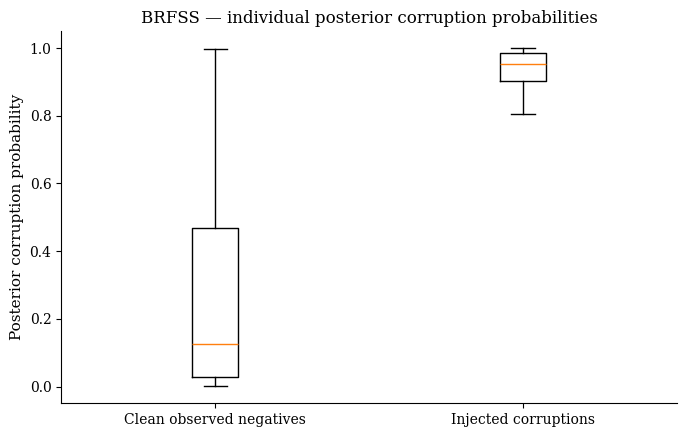

In [17]:
# Summarise the main BRFSS posterior results.
if not diag_b_axis["converged"]:
    warnings.warn(
        "The BRFSS fit did not pass the diagnostic gate. "
        "Mechanism-recovery results should not be interpreted."
    )

# Pull out the main posterior draws.
c_draw = fit_b_axis.stan_variable("c")
q_draw = fit_b_axis.stan_variable("q")
z_b = fit_b_axis.stan_variable("z_prob").mean(axis=0)


# Compare c and q with the injected values.
parameter_summary_b = pd.DataFrame([
    {
        "Parameter": "c",
        "Truth": C_B_TRUE,
        "Posterior mean": c_draw.mean(),
        "2.5%": np.quantile(c_draw, 0.025),
        "97.5%": np.quantile(c_draw, 0.975),
    },
    {
        "Parameter": "q",
        "Truth": Q_APPLIED,
        "Posterior mean": q_draw.mean(),
        "2.5%": np.quantile(q_draw, 0.025),
        "97.5%": np.quantile(q_draw, 0.975),
    },
])

display(
    parameter_summary_b.style
    .format({
        "Truth": "{:.3f}",
        "Posterior mean": "{:.3f}",
        "2.5%": "{:.3f}",
        "97.5%": "{:.3f}",
    })
    .hide(axis="index")
)

parameter_summary_b.to_csv(
    RESULT_DIR / "highrep_brfss_axis_parameter_recovery.csv",
    index=False,
)


# Localisation using the posterior corruption probabilities.
bayes_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    z_b,
)


# Response-probability-only ranking for comparison.
beta0_draw = fit_b_axis.stan_variable("beta0")
beta_draw = fit_b_axis.stan_variable("beta")

eta_draw = (
    beta0_draw[:, None]
    + beta_draw @ Xb_bayes.T
)

response_prob_b = sigmoid(eta_draw).mean(axis=0)

response_only_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    response_prob_b,
)


# Compare the three ranking approaches on the same candidate set.
comparison_b = pd.DataFrame([
    {
        "Method": "Bayesian posterior",
        "Candidate negatives": bayes_metrics_b["n_candidates"],
        "Corrupted labels": bayes_metrics_b["n_corrupted"],
        "Ranked AUC": bayes_metrics_b["ranked_auc"],
        "Precision@k": bayes_metrics_b["precision_at_k"],
    },
    {
        "Method": "Response probability only",
        "Candidate negatives": response_only_metrics_b["n_candidates"],
        "Corrupted labels": response_only_metrics_b["n_corrupted"],
        "Ranked AUC": response_only_metrics_b["ranked_auc"],
        "Precision@k": response_only_metrics_b["precision_at_k"],
    },
    {
        "Method": "Confident learning",
        "Candidate negatives": cl_metrics_b["n_candidates"],
        "Corrupted labels": cl_metrics_b["n_corrupted"],
        "Ranked AUC": cl_metrics_b["ranked_auc"],
        "Precision@k": cl_metrics_b["precision_at_k"],
    },
])

display(
    comparison_b.style
    .format({
        "Candidate negatives": "{:,}",
        "Corrupted labels": "{:,}",
        "Ranked AUC": "{:.5f}",
        "Precision@k": "{:.3f}",
    })
    .hide(axis="index")
)

comparison_b.to_csv(
    RESULT_DIR / "highrep_brfss_localisation_comparison.csv",
    index=False,
)


# Compare corrupted observations with clean observed negatives.
neg_b = yb_bayes_obs == 0
clean_neg_b = neg_b & ~flips_b

posterior_group_summary_b = pd.DataFrame({
    "Group": [
        "Injected corruptions",
        "Clean observed negatives",
    ],
    "N": [
        int(flips_b.sum()),
        int(clean_neg_b.sum()),
    ],
    "Mean posterior probability": [
        z_b[flips_b].mean(),
        z_b[clean_neg_b].mean(),
    ],
    "Maximum posterior probability": [
        z_b[flips_b].max(),
        z_b[clean_neg_b].max(),
    ],
})

display(
    posterior_group_summary_b.style
    .format({
        "N": "{:,}",
        "Mean posterior probability": "{:.3f}",
        "Maximum posterior probability": "{:.4f}",
    })
    .hide(axis="index")
)

posterior_group_summary_b.to_csv(
    RESULT_DIR / "highrep_brfss_posterior_probability_groups.csv",
    index=False,
)


# Check the fitted soft region at the posterior mean threshold.
c_mean_b = c_draw.mean()

r_fitted_b = sigmoid(
    KAPPA * (Xb_bayes[:, 0] - c_mean_b)
)

fitted_region_summary_b = pd.DataFrame({
    "Metric": [
        "Posterior mean c",
        "Minimum observed boundary score",
        "c minus minimum score",
        "Mean fitted soft membership",
        "Share with fitted membership > 0.9",
    ],
    "Value": [
        c_mean_b,
        Xb_bayes[:, 0].min(),
        c_mean_b - Xb_bayes[:, 0].min(),
        r_fitted_b.mean(),
        np.mean(r_fitted_b > 0.9),
    ],
})

display(
    fitted_region_summary_b.style
    .format({
        "Value": "{:.4f}",
    })
    .hide(axis="index")
)

fitted_region_summary_b.to_csv(
    RESULT_DIR / "highrep_brfss_fitted_region_summary.csv",
    index=False,
)


# Highest posterior corruption probabilities among observed negatives.
raw_bayes_b = (
    Xb_train_raw
    .iloc[idx_bayes_b]
    .reset_index(drop=True)
)

candidate_idx_b = np.where(neg_b)[0]

top_idx_b = candidate_idx_b[
    np.argsort(z_b[candidate_idx_b])[::-1][:10]
]

top10_b = pd.DataFrame({
    "Posterior probability": z_b[top_idx_b],
    "Ref. y": yb_bayes_true[top_idx_b],
    "Injected": np.where(flips_b[top_idx_b], "Yes", "No"),
    "BMI": raw_bayes_b.loc[top_idx_b, "BMI"].to_numpy(),
    "GenHlth": raw_bayes_b.loc[top_idx_b, "GenHlth"].to_numpy(),
    "Age": raw_bayes_b.loc[top_idx_b, "Age"].to_numpy(),
    "HighBP": raw_bayes_b.loc[top_idx_b, "HighBP"].to_numpy(),
    "Income": raw_bayes_b.loc[top_idx_b, "Income"].to_numpy(),
})

display(
    top10_b.style
    .format({
        "Posterior probability": "{:.4f}",
        "BMI": "{:.0f}",
        "GenHlth": "{:.0f}",
        "Age": "{:.0f}",
        "HighBP": "{:.0f}",
        "Income": "{:.0f}",
    })
    .hide(axis="index")
)

top10_b.to_csv(
    RESULT_DIR / "highrep_brfss_top10_posterior_corruption_probabilities.csv",
    index=False,
)


# Plot the posterior probabilities for clean negatives and injected corruptions.
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.boxplot(
    [
        z_b[clean_neg_b],
        z_b[flips_b],
    ],
    tick_labels=[
        "Clean observed negatives",
        "Injected corruptions",
    ],
    showfliers=False,
)

ax.set_ylabel("Posterior corruption probability")
ax.set_title("BRFSS — individual posterior corruption probabilities")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_brfss_posterior_corruption_probabilities.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "fig_ch2_brfss_posterior_corruption_probabilities.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Main-fit interpretation

The main BRFSS fit should be interpreted along two axes:

- **localisation:** how well the posterior corruption probabilities rank the injected corruptions;

- **mechanism recovery:** whether \(c\) and \(q\) recover their known semi-synthetic values.

A well-converged posterior does not by itself imply successful recovery of the corruption mechanism. The following diagnostics are used to investigate why mechanism recovery deteriorates when the model is fitted to the recorded BRFSS labels.

## 2.6a Response-versus-geometry diagnostic

The main BRFSS fit converges, but the estimated threshold is far below the generating value. This diagnostic checks whether the fitted susceptible region has expanded to cover almost the whole sample, and whether the strong corruption ranking is therefore mainly coming from the fitted response probabilities.

The response-only score is the posterior mean of

$$
p_i = \operatorname{logit}^{-1}(\beta_0 + x_i^\top\beta),
$$

averaged across posterior draws. It is evaluated on the same observed-negative candidates as the Bayesian posterior and confident-learning rankings.

In [18]:
def posterior_mean_response_probability(fit, X, batch_size=250):
    """Average fitted response probabilities over posterior draws."""
    beta0_draws = np.asarray(fit.stan_variable("beta0")).reshape(-1)
    beta_draws = np.asarray(fit.stan_variable("beta"))

    if beta_draws.ndim != 2:
        raise ValueError(
            f"Expected beta draws with shape (draws, p); got {beta_draws.shape}."
        )
    if beta_draws.shape[1] != X.shape[1]:
        raise ValueError(
            f"Feature mismatch: beta has {beta_draws.shape[1]} columns, "
            f"but X has {X.shape[1]}."
        )

    probability_sum = np.zeros(X.shape[0], dtype=float)

    # Work through the posterior draws in batches.
    for start in range(0, len(beta0_draws), batch_size):
        stop = min(start + batch_size, len(beta0_draws))

        # Logistic response probability for each observation in each draw.
        logits = (
            beta0_draws[start:stop, None]
            + beta_draws[start:stop] @ X.T
        )

        probability_sum += sigmoid(
            np.clip(logits, -40.0, 40.0)
        ).sum(axis=0)

    return probability_sum / len(beta0_draws)


# Fitted soft region at the posterior mean threshold.
c_hat_b = float(c_draw.mean())
boundary_min_b = float(Xb_bayes[:, 0].min())

r_fitted_b = sigmoid(
    KAPPA * (Xb_bayes[:, 0] - c_hat_b)
)

# Average the fitted response probabilities over posterior draws.
p_hat_b = posterior_mean_response_probability(
    fit_b_axis,
    Xb_bayes,
)

# Rank the same observed negatives using response probability alone.
response_only_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    p_hat_b,
)

# Check how far the fitted susceptible region has expanded.
brfss_response_geometry = pd.DataFrame([{
    "c_true": C_B_TRUE,
    "c_hat": c_hat_b,
    "boundary_score_min": boundary_min_b,
    "c_minus_min": c_hat_b - boundary_min_b,
    "mean_fitted_membership": float(r_fitted_b.mean()),
    "share_membership_gt_0.5": float(np.mean(r_fitted_b > 0.5)),
    "share_membership_gt_0.9": float(np.mean(r_fitted_b > 0.9)),
}])

# Compare all three ranking approaches on the same candidate set.
brfss_ranking_comparison = pd.DataFrame([
    {"method": "Bayesian posterior", **bayes_metrics_b},
    {"method": "Response probability only", **response_only_metrics_b},
    {"method": "Confident learning", **cl_metrics_b},
])

display(brfss_response_geometry)
display(brfss_ranking_comparison)

# The Bayesian and response-only AUCs should be almost identical here.
print(
    "Bayesian-minus-response-only ranked AUC:",
    bayes_metrics_b["ranked_auc"]
    - response_only_metrics_b["ranked_auc"],
)

,c_true,c_hat,boundary_score_min,c_minus_min,mean_fitted_membership,share_membership_gt_0.5,share_membership_gt_0.9
0,1.461407,-2.268871,-2.327101,0.058229,0.993963,0.999833,0.9875


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior,5240,76,0.950387,0.263158
1,Response probability only,5240,76,0.950343,0.263158
2,Confident learning,5240,76,0.935114,0.263158


Bayesian-minus-response-only ranked AUC: 4.331607485008604e-05


## 2.6b Posterior predictive check (main fit)

In [19]:
# Check that this is the same BRFSS fit before running the PPC.
auc_val = bayes_metrics_b["ranked_auc"]

assert abs(c_draw.mean() - (-2.269)) < 0.005, (
    f"c mean {c_draw.mean():.4f} does not match -2.269"
)

assert abs(q_draw.mean() - 0.658) < 0.005, (
    f"q mean {q_draw.mean():.4f} does not match 0.658"
)

assert abs(auc_val - 0.9504) < 0.001, (
    f"ranked AUC {auc_val:.4f} does not match 0.9504"
)

print(
    f"Fit check passed: "
    f"c={c_draw.mean():.4f}, "
    f"q={q_draw.mean():.4f}, "
    f"AUC={auc_val:.4f}"
)

Fit check passed: c=-2.2689, q=0.6580, AUC=0.9504


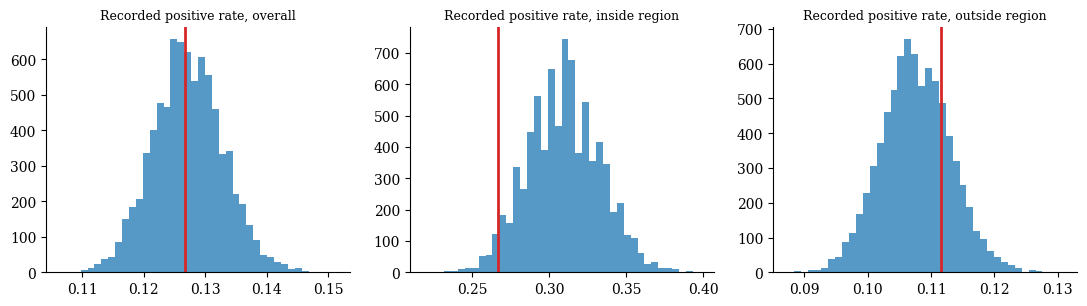

,statistic,observed,ppc_mean,ppc_2.5,ppc_97.5,two_sided_p
0,overall,0.126667,0.127172,0.116167,0.138500,0.95825
1,inside region,0.266781,0.309407,0.265060,0.354561,0.06900
2,outside region,0.111644,0.107634,0.097250,0.118657,0.46975


In [20]:
# Posterior predictive check for the main BRFSS fit.
# Simulate recorded labels from each posterior draw and compare
# positive rates overall and on either side of the original boundary.

from scipy.special import expit

rng_ppc = np.random.default_rng(SEED + 900)

# Pull out the posterior draws.
beta0_d = np.asarray(fit_b_axis.stan_variable("beta0")).reshape(-1)
beta_d = np.asarray(fit_b_axis.stan_variable("beta"))
c_d = np.asarray(fit_b_axis.stan_variable("c")).reshape(-1)
q_d = np.asarray(fit_b_axis.stan_variable("q")).reshape(-1)

X_ppc = np.asarray(Xb_bayes, float)
inside = np.asarray(region_b_bayes, bool)

# Latent response probability for each draw and observation.
p_mat = expit(
    beta0_d[:, None]
    + beta_d @ X_ppc.T
)

# Soft region membership. The boundary score is the first column.
r_mat = expit(
    KAPPA * (X_ppc[:, 0][None, :] - c_d[:, None])
)

# Probability of recording a positive label under one-sided corruption.
prob_y1 = (
    1.0 - q_d[:, None] * r_mat
) * p_mat

# One replicated label vector for each posterior draw.
y_rep = rng_ppc.random(prob_y1.shape) < prob_y1

# Compare the observed positive rates with their replicated distributions.
stats = {
    "overall": (
        y_rep.mean(axis=1),
        yb_bayes_obs.mean(),
    ),
    "inside region": (
        y_rep[:, inside].mean(axis=1),
        yb_bayes_obs[inside].mean(),
    ),
    "outside region": (
        y_rep[:, ~inside].mean(axis=1),
        yb_bayes_obs[~inside].mean(),
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
rows = []

for ax, (name, (rep, obs)) in zip(axes, stats.items()):
    ax.hist(rep, bins=40, color="tab:blue", alpha=0.75)
    ax.axvline(obs, color="tab:red", lw=2)
    ax.set_title(f"Recorded positive rate, {name}", fontsize=9)

    # Two-sided posterior predictive tail probability.
    p_two = 2 * min(
        (rep >= obs).mean(),
        (rep <= obs).mean(),
    )

    rows.append({
        "statistic": name,
        "observed": obs,
        "ppc_mean": rep.mean(),
        "ppc_2.5": np.quantile(rep, 0.025),
        "ppc_97.5": np.quantile(rep, 0.975),
        "two_sided_p": min(p_two, 1.0),
    })

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_brfss_ppc.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_ppc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

ppc_summary_b = pd.DataFrame(rows)
display(ppc_summary_b)

## 2.7 Diagnostic A — verify region alignment and soft-boundary approximation

In [21]:
# Check that the stored region matches the boundary score and true threshold.
check = pd.DataFrame({
    "boundary_score": Xb_bayes[:, 0],
    "inside_region_from_score": Xb_bayes[:, 0] > C_B_TRUE,
    "inside_region_used_for_corruption": region_b_bayes,
})

mismatch_count = (
    check["inside_region_from_score"]
    != check["inside_region_used_for_corruption"]
).sum()

print("Mismatch count:", mismatch_count)
print(check["boundary_score"].describe())
print("c_true =", C_B_TRUE)


# Look at the soft version of the true susceptible region.
r_true_soft = sigmoid(
    KAPPA * (Xb_bayes[:, 0] - C_B_TRUE)
)

print("Mean soft membership overall:", r_true_soft.mean())

print(
    "Mean soft membership inside hard region:",
    r_true_soft[region_b_bayes].mean()
)

print(
    "Mean soft membership outside hard region:",
    r_true_soft[~region_b_bayes].mean()
)


# Check how many observations lie close to the boundary.
print(
    "Proportion within 0.2 of boundary:",
    np.mean(
        np.abs(Xb_bayes[:, 0] - C_B_TRUE) < 0.2
    )
)

Mismatch count: 0
count    6000.000000
mean       -0.007747
std         1.091435
min        -2.327101
25%        -0.807926
50%        -0.146073
75%         0.622944
max         6.000073
Name: boundary_score, dtype: float64
c_true = 1.461407312209662
Mean soft membership overall: 0.10414249566616587
Mean soft membership inside hard region: 0.8542937197408458
Mean soft membership outside hard region: 0.02371476708388333
Proportion within 0.2 of boundary: 0.05


## 2.8 Diagnostic B — fix the true threshold and re-estimate \(q\)

This checks whether the poor recovery of \(q\) is mainly due to compensation between the threshold \(c\) and corruption rate \(q\).

A separate temporary Stan model is used with the true threshold fixed. The Chapter 0 model is left unchanged.

In [23]:
# Fit the same model with c fixed at its generating value.
fixed_c_stan = r"""
data {
  int<lower=1> n;
  int<lower=1> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;

  int<lower=1, upper=p> boundary_dim;
  real<lower=0> kappa;
  real c_fixed;
}

parameters {
  real beta0;
  vector[p] beta;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta ~ normal(0, 1);
  q ~ beta(2, 5);

  for (i in 1:n) {
    real p_true = inv_logit(
      beta0 + X[i] * beta
    );

    real r = inv_logit(
      kappa * (
        X[i, boundary_dim] - c_fixed
      )
    );

    real w = q * r;

    if (y[i] == 1) {
      target += log(p_true) + log1m(w);
    } else {
      target += log_sum_exp(
        log1m(p_true),
        log(p_true) + log(w)
      );
    }
  }
}
"""

# Keep this diagnostic model separate from the main Stan file.
fixed_c_path = (
    STAN_DIR / "corruption_model_axis_FIXED_C_DIAGNOSTIC.stan"
)

fixed_c_path.write_text(fixed_c_stan)

fixed_c_model = CmdStanModel(
    stan_file=str(fixed_c_path)
)

# Same BRFSS sample and settings, but c is fixed at the true value.
fixed_c_data = {
    "n": len(yb_bayes_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": yb_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_fixed": C_B_TRUE,
}

# Use the same sampling settings as the main axis-supplied fit.
fit_b_fixed_c = fixed_c_model.sample(
    data=fixed_c_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 450,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

# Check convergence before looking at q.
diag_fixed_c, core_fixed_c = core_sampler_diagnostics(
    fit_b_fixed_c
)

display(pd.DataFrame([diag_fixed_c]))

# Compare the fitted q with the injected value.
q_fixed_c = fit_b_fixed_c.stan_variable("q")

fixed_c_summary = pd.DataFrame([{
    "parameter": "q",
    "true": Q_APPLIED,
    "posterior_mean": q_fixed_c.mean(),
    "ci_2.5": np.quantile(q_fixed_c, 0.025),
    "ci_97.5": np.quantile(q_fixed_c, 0.975),
}])

display(fixed_c_summary)

11:46:49 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpvx79zfiu/tmpddyres3d.stan to exe file /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/stan/corruption_model_axis_FIXED_C_DIAGNOSTIC
11:46:53 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/stan/corruption_model_axis_FIXED_C_DIAGNOSTIC
11:46:53 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

11:47:30 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.00095,6389.05,True


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,q,0.35,0.587846,0.500629,0.663618


## 2.8a Diagnostic B' — likelihood comparison at the fixed and estimated thresholds

This compares the main BRFSS fit, where \(c\) is estimated, with the fixed-\(c\) diagnostic on the same data and using the same marginal likelihood.

The fixed-\(c\) model does not save `log_lik`, so the likelihood is evaluated directly in Python using the same one-sided formulation as the Stan model. Both the likelihood at the posterior means and the posterior-averaged likelihood are compared.

In [24]:
# Compare the likelihood under the estimated and fixed thresholds.

from scipy.special import expit

BOUND_COL = 0

X_cmp = np.asarray(Xb_bayes, float)
y_cmp = np.asarray(yb_bayes_obs, int)


def axis_total_loglik(
    beta0,
    beta,
    c,
    q,
    X,
    y,
    kappa=KAPPA,
    bcol=BOUND_COL,
):
    """Total log-likelihood for the one-sided axis model."""
    pr = expit(
        beta0 + X @ np.asarray(beta, float)
    )

    r = expit(
        kappa * (X[:, bcol] - c)
    )

    w = q * r

    lik = np.where(
        y == 1,
        (1.0 - w) * pr,
        (1.0 - pr) + w * pr,
    )

    return float(
        np.log(
            np.clip(lik, 1e-300, None)
        ).sum()
    )


def _post_mean_params(fit, c_value=None):
    """Posterior mean parameters for the likelihood comparison."""
    beta0 = float(
        np.asarray(
            fit.stan_variable("beta0")
        ).mean()
    )

    beta = np.asarray(
        fit.stan_variable("beta")
    ).mean(axis=0)

    q = float(
        np.asarray(
            fit.stan_variable("q")
        ).mean()
    )

    if c_value is None:
        c = float(
            np.asarray(
                fit.stan_variable("c")
            ).mean()
        )
    else:
        c = float(c_value)

    return beta0, beta, c, q


# First compare the likelihood at the posterior mean parameters.
b0_m, be_m, c_m, q_m = _post_mean_params(
    fit_b_axis
)

b0_f, be_f, c_f, q_f = _post_mean_params(
    fit_b_fixed_c,
    c_value=C_B_TRUE,
)

ll_main = axis_total_loglik(
    b0_m,
    be_m,
    c_m,
    q_m,
    X_cmp,
    y_cmp,
)

ll_fixed = axis_total_loglik(
    b0_f,
    be_f,
    c_f,
    q_f,
    X_cmp,
    y_cmp,
)


# Also compare the average log-likelihood across posterior draws.
# Thin the draws here to keep the calculation quick.
def _posterior_avg_loglik(fit, c_value=None, thin=8):
    b0_d = np.asarray(
        fit.stan_variable("beta0")
    )[::thin]

    be_d = np.asarray(
        fit.stan_variable("beta")
    )[::thin]

    q_d = np.asarray(
        fit.stan_variable("q")
    )[::thin]

    if c_value is None:
        c_d = np.asarray(
            fit.stan_variable("c")
        )[::thin]
    else:
        c_d = np.full(
            len(q_d),
            float(c_value),
        )

    total_loglik = np.empty(len(q_d))

    for i in range(len(q_d)):
        total_loglik[i] = axis_total_loglik(
            float(b0_d[i]),
            be_d[i],
            float(c_d[i]),
            float(q_d[i]),
            X_cmp,
            y_cmp,
        )

    return float(total_loglik.mean()), len(q_d)


avg_main, nd_m = _posterior_avg_loglik(
    fit_b_axis
)

avg_fixed, nd_f = _posterior_avg_loglik(
    fit_b_fixed_c,
    c_value=C_B_TRUE,
)


# Put the two fits side by side.
collapse_cmp = pd.DataFrame([
    {
        "fit": "main (c estimated)",
        "c": round(c_m, 3),
        "q": round(q_m, 3),
        "loglik_at_post_mean": round(ll_main, 2),
        "posterior_avg_loglik": round(avg_main, 2),
        "draws_used": nd_m,
    },
    {
        "fit": "fixed-c diagnostic",
        "c": round(c_f, 3),
        "q": round(q_f, 3),
        "loglik_at_post_mean": round(ll_fixed, 2),
        "posterior_avg_loglik": round(avg_fixed, 2),
        "draws_used": nd_f,
    },
])

display(collapse_cmp)


# Positive values mean the estimated-c fit has the higher likelihood.
gap_plug = ll_main - ll_fixed
gap_avg = avg_main - avg_fixed

print(
    f"Gap at posterior means (main - fixed): "
    f"{gap_plug:+.2f} "
    f"({gap_plug / len(y_cmp):+.5f} per observation)"
)

print(
    f"Average gap over posterior draws (main - fixed): "
    f"{gap_avg:+.2f}"
)

,fit,c,q,loglik_at_post_mean,posterior_avg_loglik,draws_used
0,main (c estimated),-2.269,0.658,-1885.28,-1889.31,1000
1,fixed-c diagnostic,1.461,0.588,-1892.61,-1896.63,1000


Gap at posterior means (main - fixed): +7.33 (+0.00122 per observation)
Average gap over posterior draws (main - fixed): +7.33


## 2.9 Diagnostic C — realistic \(X\), model-correct logistic \(Y\)

This diagnostic separates the effect of the realistic BRFSS covariates from possible response-model mismatch.

The BRFSS covariates are kept fixed, but the latent response is generated from the same logistic model assumed by Stan. The same susceptible region and \(q=0.35\) are then used to inject one-sided corruption.

If recovery of \(c\) and \(q\) improves here, the realistic covariate structure alone is unlikely to explain the poor recovery in the main BRFSS fit. This would instead suggest that mismatch between the logistic response model and the recorded BRFSS labels contributes to the response–corruption confounding.

In [25]:
# Generate a model-correct response on the same BRFSS covariates.
rng_diag = np.random.default_rng(SEED + 800)

# Use a logistic fit to set realistic coefficient values.
lr_diag = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=SEED,
)

lr_diag.fit(
    Xb_bayes,
    yb_bayes_true,
)

beta0_diag = float(
    lr_diag.intercept_[0]
)

beta_diag = lr_diag.coef_[0].copy()


# Generate a new latent response from the logistic model.
eta_diag = (
    beta0_diag
    + Xb_bayes @ beta_diag
)

p_diag = sigmoid(eta_diag)

y_diag_true = rng_diag.binomial(
    1,
    p_diag,
)


# Inject the same one-sided corruption as in the main BRFSS experiment.
y_diag_obs, flips_diag = corrupt_one_sided(
    y_diag_true,
    region_b_bayes,
    Q_APPLIED,
    rng_diag,
)


# Check the generated sample before fitting the Bayesian model.
print("n =", len(y_diag_true))

print(
    "Latent positive prevalence:",
    y_diag_true.mean()
)

print(
    "Region share:",
    region_b_bayes.mean()
)

print(
    "Eligible positives:",
    (
        (y_diag_true == 1)
        & region_b_bayes
    ).sum()
)

print(
    "Injected corruptions:",
    flips_diag.sum()
)

print(
    "Effective corruption rate:",
    flips_diag.mean()
)


# These are the generating values for this diagnostic.
print("\nTrue beta0:", beta0_diag)
print("True beta:", beta_diag)
print("True c:", C_B_TRUE)
print("True q:", Q_APPLIED)

n = 6000
Latent positive prevalence: 0.1425
Region share: 0.09683333333333333
Eligible positives: 263
Injected corruptions: 87
Effective corruption rate: 0.0145

True beta0: -2.358715549161293
True beta: [ 0.75839951 -0.10166474  0.41301221  0.03656521  0.46711448 -0.10941284]
True c: 1.461407312209662
True q: 0.35


In [26]:
# Fit the axis-supplied model to the model-correct response.
stan_data_diag = {
    "n": len(y_diag_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": y_diag_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

# Use the same sampling settings as the main BRFSS fit.
fit_b_model_correct = model_axis.sample(
    data=stan_data_diag,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 801,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

# Check convergence before looking at recovery.
diag_model_correct, core_model_correct = core_sampler_diagnostics(
    fit_b_model_correct
)

display(
    pd.DataFrame([
        diag_model_correct
    ])
)

11:53:32 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

11:54:31 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.00113,7282.31,True


In [27]:
# Pull out the posterior draws from the model-correct fit.
c_mc = fit_b_model_correct.stan_variable("c")
q_mc = fit_b_model_correct.stan_variable("q")
beta0_mc = fit_b_model_correct.stan_variable("beta0")
beta_mc = fit_b_model_correct.stan_variable("beta")


# Compare the main parameters with their generating values.
recovery_mc = pd.DataFrame([
    {
        "parameter": "beta0",
        "true": beta0_diag,
        "posterior_mean": beta0_mc.mean(),
        "ci_2.5": np.quantile(beta0_mc, 0.025),
        "ci_97.5": np.quantile(beta0_mc, 0.975),
    },
    {
        "parameter": "c",
        "true": C_B_TRUE,
        "posterior_mean": c_mc.mean(),
        "ci_2.5": np.quantile(c_mc, 0.025),
        "ci_97.5": np.quantile(c_mc, 0.975),
    },
    {
        "parameter": "q",
        "true": Q_APPLIED,
        "posterior_mean": q_mc.mean(),
        "ci_2.5": np.quantile(q_mc, 0.025),
        "ci_97.5": np.quantile(q_mc, 0.975),
    },
])

display(recovery_mc)


# Check recovery of the individual response coefficients as well.
beta_recovery_mc = pd.DataFrame({
    "parameter": [
        f"beta[{j}]"
        for j in range(
            1,
            len(beta_diag) + 1
        )
    ],
    "true": beta_diag,
    "posterior_mean": beta_mc.mean(axis=0),
    "ci_2.5": np.quantile(
        beta_mc,
        0.025,
        axis=0
    ),
    "ci_97.5": np.quantile(
        beta_mc,
        0.975,
        axis=0
    ),
})

display(beta_recovery_mc)

,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,beta0,-2.358716,-2.389131,-2.501653,-2.279226
1,c,1.461407,1.655554,1.265581,2.081054
2,q,0.350000,0.340386,0.185664,0.472351


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,beta[1],0.758400,0.812294,0.681514,0.945964
1,beta[2],-0.101665,-0.174716,-0.272498,-0.074474
2,beta[3],0.413012,0.419220,0.327346,0.511196
3,beta[4],0.036565,0.073415,-0.007326,0.151454
4,beta[5],0.467114,0.464446,0.359583,0.572529
5,beta[6],-0.109413,-0.030789,-0.120267,0.059591


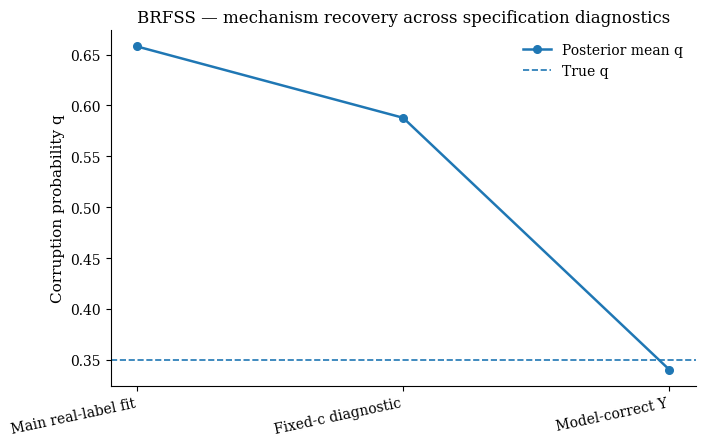

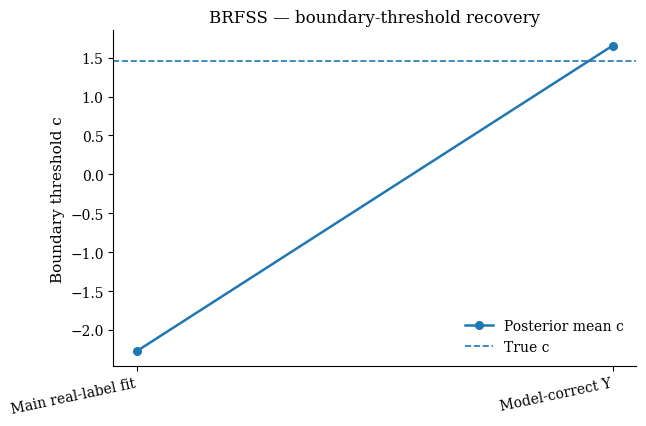

In [28]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
# Compact visual summary of the BRFSS mechanism-recovery diagnostics.
# The main fit estimates both c and q; the fixed-c diagnostic estimates q only;
# the model-correct-Y diagnostic again estimates both c and q.

recovery_plot = pd.DataFrame([
    {
        "fit": "Main real-label fit",
        "c_estimate": float(c_draw.mean()),
        "q_estimate": float(q_draw.mean()),
    },
    {
        "fit": "Fixed-c diagnostic",
        "c_estimate": np.nan,
        "q_estimate": float(q_fixed_c.mean()),
    },
    {
        "fit": "Model-correct Y",
        "c_estimate": float(c_mc.mean()),
        "q_estimate": float(q_mc.mean()),
    },
])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(recovery_plot))

ax.plot(
    x,
    recovery_plot["q_estimate"],
    marker="o",
    label="Posterior mean q",
)
ax.axhline(
    Q_APPLIED,
    linestyle="--",
    linewidth=1.2,
    label="True q",
)
ax.set_xticks(x)
ax.set_xticklabels(recovery_plot["fit"], rotation=12, ha="right")
ax.set_ylabel("Corruption probability q")
ax.set_title("BRFSS — mechanism recovery across specification diagnostics")
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_recovery_diagnostics.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_recovery_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Threshold recovery is shown separately because c and q are on different scales.
fig, ax = plt.subplots(figsize=(6.6, 4.4))
c_names = ["Main real-label fit", "Model-correct Y"]
c_estimates = [float(c_draw.mean()), float(c_mc.mean())]
ax.plot(
    np.arange(len(c_names)),
    c_estimates,
    marker="o",
    label="Posterior mean c",
)
ax.axhline(
    C_B_TRUE,
    linestyle="--",
    linewidth=1.2,
    label="True c",
)
ax.set_xticks(np.arange(len(c_names)))
ax.set_xticklabels(c_names, rotation=12, ha="right")
ax.set_ylabel("Boundary threshold c")
ax.set_title("BRFSS — boundary-threshold recovery")
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_threshold_recovery.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_threshold_recovery.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Specification diagnostic interpretation

The three BRFSS fits answer slightly different questions:

1. **Main recorded-label fit:** can the model recover the injected corruption mechanism when both the covariates and recorded response relationship come from BRFSS?

2. **Fixed-\(c\) fit:** how much does recovery of \(q\) improve when the threshold is fixed at its generating value?

3. **Model-correct-\(Y\) fit:** how does recovery change when the same BRFSS covariates are paired with responses generated from the assumed logistic model?

Together, these diagnostics separate convergence from mechanism recovery and help show where the poor recovery in the main BRFSS fit is coming from.

## 2.10 Individual posterior uncertainty

This table is a semi-synthetic validation check. It does not identify real-world label errors in BRFSS. Instead, it asks whether the posterior assigns high corruption probability to observations whose labels were deliberately altered in the experiment.

In [29]:
# Rank observed negatives by posterior corruption probability.
candidate_idx_b = np.flatnonzero(
    yb_bayes_obs == 0
)

rank_idx = candidate_idx_b[
    np.argsort(
        z_b[candidate_idx_b]
    )[::-1][:20]
]


# Pull the original BRFSS variables for the highest-ranked observations.
top_b = Xb_train_raw.iloc[
    idx_bayes_b[rank_idx]
][
    [
        "BMI",
        "GenHlth",
        "Age",
        "HighBP",
        "DiffWalk",
        "Income",
    ]
].copy()


# Add the posterior score and the known semi-synthetic labels.
top_b.insert(
    0,
    "posterior_corruption_prob",
    z_b[rank_idx]
)

top_b.insert(
    1,
    "observed_label",
    yb_bayes_obs[rank_idx]
)

top_b.insert(
    2,
    "reference_label",
    yb_bayes_true[rank_idx]
)

top_b.insert(
    3,
    "injected_corruption",
    flips_b[rank_idx]
)

top_b.insert(
    4,
    "inside_true_region",
    region_b_bayes[rank_idx]
)


# Inspect the highest posterior corruption probabilities.
display(
    top_b.reset_index(drop=True)
)

,posterior_corruption_prob,observed_label,reference_label,injected_corruption,inside_true_region,BMI,GenHlth,Age,HighBP,DiffWalk,Income
0,0.999314,0,1,True,True,51.0,5.0,11.0,1.0,1.0,1.0
1,0.998639,0,1,True,True,54.0,4.0,11.0,1.0,1.0,2.0
2,0.998360,0,0,False,True,51.0,5.0,9.0,1.0,1.0,3.0
3,0.998339,0,1,True,True,55.0,5.0,6.0,1.0,1.0,1.0
4,0.998255,0,0,False,True,69.0,5.0,1.0,1.0,0.0,1.0
5,0.997821,0,1,True,True,63.0,4.0,5.0,1.0,1.0,2.0
6,0.997783,0,0,False,True,53.0,5.0,6.0,1.0,1.0,1.0
7,0.997450,0,1,True,True,45.0,5.0,11.0,1.0,1.0,4.0
8,0.996052,0,1,True,True,45.0,5.0,9.0,1.0,1.0,3.0
9,0.996024,0,1,True,True,41.0,5.0,11.0,1.0,1.0,3.0


## 2.11 General-boundary BRFSS stress test

Chapter 1 Experiment 4 showed that learning $\alpha$ can lead to competing posterior modes. The same BRFSS sample is therefore fitted with the general-boundary model as a stress test.

The true semi-synthetic boundary direction is the first axis of the transformed feature matrix,

$$
\alpha_{\text{true}} = (1, 0, \ldots, 0).
$$

The learned direction is only interpreted if the fit passes the same diagnostic checks used in Chapter 1. A diagnostic failure is still informative here, as it shows whether the learned-boundary model remains stable on the applied data.

In [30]:
RUN_GENERAL_BRFSS = True

if RUN_GENERAL_BRFSS:
    # Fit the learned-boundary model to the same BRFSS sample.
    if not GENERAL_STAN.exists():
        raise FileNotFoundError(
            f"Missing {GENERAL_STAN}"
        )

    model_general = CmdStanModel(
        stan_file=str(GENERAL_STAN)
    )

    # Same data and priors as before, but alpha is now estimated.
    data_general_b = {
        "n": len(yb_bayes_obs),
        "p": Xb_bayes.shape[1],
        "X": Xb_bayes.tolist(),
        "y": yb_bayes_obs.astype(int).tolist(),
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.5,
    }

    # Use the stricter sampling settings for the learned-boundary fit.
    fit_b_general = model_general.sample(
        data=data_general_b,
        chains=4,
        parallel_chains=4,
        iter_warmup=1000,
        iter_sampling=2000,
        seed=SEED + 500,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=True,
    )

    # Check the fit before interpreting the learned direction.
    diag_b_general, core_b_general = core_sampler_diagnostics(
        fit_b_general
    )

    display(
        pd.DataFrame([
            diag_b_general
        ])
    )

    display(
        core_b_general
    )

    if diag_b_general["converged"]:
        # True direction is the first axis of the transformed matrix.
        alpha_draw = fit_b_general.stan_variable(
            "alpha"
        )

        alpha_true_b = np.zeros(
            Xb_bayes.shape[1]
        )
        alpha_true_b[0] = 1.0

        # Cosine similarity measures recovery of the boundary direction.
        cosine = (
            alpha_draw
            @ alpha_true_b
        )

        # Check observation-level localisation as well.
        z_bg = fit_b_general.stan_variable(
            "z_prob"
        ).mean(axis=0)

        general_metrics_b = ranking_metrics(
            yb_bayes_obs,
            flips_b,
            z_bg,
        )

        print(
            "Mean cosine similarity:",
            cosine.mean()
        )

        print(
            "5th percentile cosine similarity:",
            np.quantile(
                cosine,
                0.05
            )
        )

        display(
            pd.DataFrame([{
                "method": "General Bayesian posterior",
                **general_metrics_b
            }])
        )

    else:
        print(
            "General fit not interpreted:"
            " diagnostics did not pass."
        )

12:03:42 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmp1mtr40ty/tmpkprnr6ug.stan to exe file /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/stan/corruption_model_general_FINAL
12:03:46 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS_Demi_Kramer_Imperial copy/high_replication/chapter2/stan/corruption_model_general_FINAL
12:03:47 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

12:09:43 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.03748,114.167,True


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
beta0,-1.051420,0.021029,0.233750,0.193177,-1.470230,-1.020700,-0.731679,170.296,221.740,0.202254,1.02030
beta[1],1.531720,0.007833,0.171196,0.173282,1.262130,1.525030,1.819530,521.012,1970.640,0.618785,1.01125
beta[2],-0.037383,0.001643,0.124814,0.124252,-0.243741,-0.037988,0.168563,5788.260,4953.530,6.874480,1.00168
beta[3],0.612189,0.019049,0.172074,0.117245,0.405059,0.568922,0.979822,114.167,279.624,0.135592,1.03748
beta[4],0.250631,0.006244,0.129406,0.120373,0.056994,0.241792,0.476565,516.345,803.331,0.613242,1.00403
beta[5],0.966495,0.003801,0.125252,0.120748,0.771892,0.960995,1.179370,1193.670,3141.790,1.417670,1.00623
beta[6],-0.350372,0.008495,0.125836,0.119784,-0.578179,-0.341910,-0.163114,260.810,440.635,0.309753,1.01269
c,-2.225120,0.105683,1.105420,1.017880,-4.016850,-2.271500,-0.482566,131.297,204.952,0.155936,1.02690
q,0.657883,0.000400,0.021281,0.020776,0.621768,0.658983,0.690616,2971.530,4588.940,3.529170,1.00268
alpha[1],0.389233,0.006512,0.304578,0.256876,-0.226287,0.451185,0.799259,2712.850,3354.710,3.221950,1.00878


Mean cosine similarity: 0.38923259263601756
5th percentile cosine similarity: -0.22628684149999997


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,General Bayesian posterior,5240,76,0.948185,0.263158


# 3. Credit default replication

The credit dataset provides a second-domain check on whether the BRFSS conclusions depend on the healthcare covariate structure.

The same setup is used:

- clean train/test split before corruption;
- one-sided $1 \to 0$ corruption;
- a prespecified halfspace;
- matched Bayesian and confident-learning localisation metrics;
- mechanism recovery interpreted only when the sampler diagnostics pass.

## 3.1 Data and clean ceiling

In [31]:
# Load the credit data and set up the clean train/test split.
if not CREDIT_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CREDIT_PATH}"
    )

credit = pd.read_csv(
    CREDIT_PATH
)

# ID is not used as a predictor.
if "ID" in credit.columns:
    credit = credit.drop(
        columns=["ID"]
    )

# Give the target a shorter name.
if "default.payment.next.month" in credit.columns:
    credit = credit.rename(
        columns={
            "default.payment.next.month": "default"
        }
    )

TARGET_C = "default"

yc = credit[TARGET_C].to_numpy(
    dtype=int
)

Xc_raw = credit.drop(
    columns=[TARGET_C]
).copy()


# Split before adding any corruption.
Xc_train_raw, Xc_test_raw, yc_train, yc_test = train_test_split(
    Xc_raw,
    yc,
    test_size=0.20,
    stratify=yc,
    random_state=SEED,
)

Xc_train_raw = Xc_train_raw.reset_index(
    drop=True
)

Xc_test_raw = Xc_test_raw.reset_index(
    drop=True
)


# Standardise using the training data only.
scaler_c_full = StandardScaler()

Xc_train_z_full = scaler_c_full.fit_transform(
    Xc_train_raw
)

Xc_test_z_full = scaler_c_full.transform(
    Xc_test_raw
)


# Clean logistic baseline before corruption.
clean_c = fit_lr(
    Xc_train_z_full,
    yc_train,
    Xc_test_z_full,
    yc_test,
)


# Quick summary of the credit data and clean baseline.
summary_credit = pd.DataFrame({
    "Metric": [
        "Rows",
        "Recorded prevalence",
        "Training observations",
        "Test observations",
        "Test prevalence",
        "Predictors",
        "Clean LR AUC",
        "Clean LR F1",
    ],
    "Value": [
        f"{len(credit):,}",
        f"{yc.mean():.3%}",
        f"{len(yc_train):,}",
        f"{len(yc_test):,}",
        f"{yc_test.mean():.3%}",
        Xc_raw.shape[1],
        f"{clean_c['auc']:.4f}",
        f"{clean_c['f1']:.4f}",
    ],
})

display(
    summary_credit.style
    .hide(axis="index")
)

Metric,Value
Rows,"30,000"
Recorded prevalence,22.120%
Training observations,"24,000"
Test observations,"6,000"
Test prevalence,22.117%
Predictors,23
Clean LR AUC,0.7081
Clean LR F1,0.4613


## 3.2 Model-aligned distress region

The distress direction combines repayment delay (`PAY_0`, larger is worse) and credit limit (`LIMIT_BAL`, smaller is worse). An orthogonal contrast is retained so that the response model can also vary independently of the boundary direction.

In [32]:
def make_credit_model_matrix(
    train_raw,
    test_raw
):
    # Variables used in the reduced credit response model.
    required = [
        "PAY_0",
        "LIMIT_BAL",
        "AGE",
        "PAY_2",
        "BILL_AMT1",
        "PAY_AMT1",
    ]

    missing = [
        c for c in required
        if c not in train_raw.columns
    ]

    if missing:
        raise KeyError(
            f"Missing expected credit columns: {missing}"
        )

    # Standardise using the training data only.
    scaler = StandardScaler()

    Ztr = scaler.fit_transform(
        train_raw[required]
    )

    Zte = scaler.transform(
        test_raw[required]
    )

    i_pay = required.index("PAY_0")
    i_lim = required.index("LIMIT_BAL")

    # Higher repayment delay and lower credit limit give a higher distress score.
    score_tr = (
        Ztr[:, i_pay]
        - Ztr[:, i_lim]
    ) / np.sqrt(2.0)

    score_te = (
        Zte[:, i_pay]
        - Zte[:, i_lim]
    ) / np.sqrt(2.0)

    # Keep the orthogonal direction in the response model.
    contrast_tr = (
        Ztr[:, i_pay]
        + Ztr[:, i_lim]
    ) / np.sqrt(2.0)

    contrast_te = (
        Zte[:, i_pay]
        + Zte[:, i_lim]
    ) / np.sqrt(2.0)

    others = [
        "AGE",
        "PAY_2",
        "BILL_AMT1",
        "PAY_AMT1",
    ]

    idx = [
        required.index(c)
        for c in others
    ]

    Xtr = np.column_stack([
        score_tr,
        contrast_tr,
        Ztr[:, idx],
    ])

    Xte = np.column_stack([
        score_te,
        contrast_te,
        Zte[:, idx],
    ])

    return (
        Xtr,
        Xte,
        [
            "boundary_score",
            "PAY0_plus_LIMITBAL_contrast",
            *others,
        ],
        scaler,
    )


# Build the reduced matrix used for the credit Bayesian analysis.
Xc_model, Xc_model_test, CREDIT_MODEL_FEATURES, credit_model_scaler = (
    make_credit_model_matrix(
        Xc_train_raw,
        Xc_test_raw,
    )
)


# Use the 93rd percentile of the training score as the hard threshold.
C_C_TRUE = float(
    np.quantile(
        Xc_model[:, 0],
        0.93
    )
)

region_c = (
    Xc_model[:, 0]
    > C_C_TRUE
)


# Check the size and label composition of the susceptible region.
credit_region_summary = pd.DataFrame({
    "Metric": [
        "Threshold c",
        "Observations inside region",
        "Region share",
        "Recorded positive rate overall",
        "Recorded positive rate inside",
        "Recorded positive rate outside",
        "Eligible positives",
    ],
    "Value": [
        C_C_TRUE,
        int(region_c.sum()),
        region_c.mean(),
        yc_train.mean(),
        yc_train[region_c].mean(),
        yc_train[~region_c].mean(),
        int(
            (
                (yc_train == 1)
                & region_c
            ).sum()
        ),
    ],
})

display(
    credit_region_summary.style
    .format({"Value": "{:.4f}"})
    .hide(axis="index")
)

Metric,Value
Threshold c,1.6359
Observations inside region,1545.0000
Region share,0.0644
Recorded positive rate overall,0.2212
Recorded positive rate inside,0.7049
Recorded positive rate outside,0.1879
Eligible positives,1089.0000


### 3.2a Pre-corruption response-model check

The same pre-corruption check is repeated for Credit using the reduced model matrix used by the Bayesian response model.

Held-out AUC, Brier score, log loss and the calibration curve are compared with a more flexible model. The aim is to check whether the linear-logistic response model is already missing structure before any corruption is added.

,dataset,model,auc,brier,log_loss,mean_abs_calibration_bin_gap
0,Credit default,Logistic,0.701069,0.148216,0.474575,0.050913
1,Credit default,Flexible HGB,0.763537,0.138217,0.439046,0.009855


Credit default: flexible-minus-logistic held-out AUC = +0.0625
Interpret this as a response-specification diagnostic, not as a formal goodness-of-fit test.


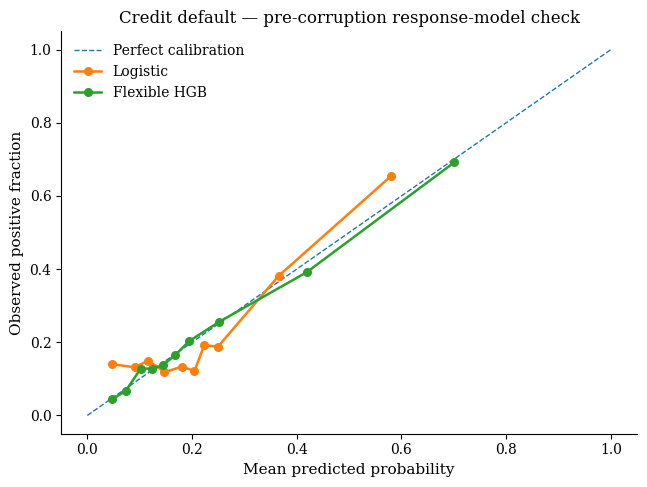

In [33]:
# Run the pre-corruption check on the reduced credit matrix.
credit_pre_corruption_check = pre_corruption_response_check(
    X_train=Xc_model,
    y_train=yc_train,
    X_test=Xc_model_test,
    y_test=yc_test,
    dataset_label="Credit default",
    file_stem="highrep_credit",
    seed=SEED,
)

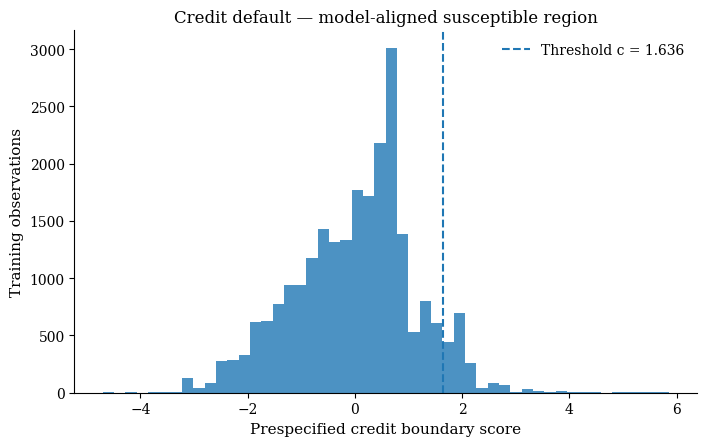

In [34]:
# Plot the prespecified credit boundary score and hard threshold.
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.hist(
    Xc_model[:, 0],
    bins=50,
    alpha=0.8,
)

ax.axvline(
    C_C_TRUE,
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold c = {C_C_TRUE:.3f}",
)

ax.set_title(
    "Credit default — model-aligned susceptible region"
)

ax.set_xlabel(
    "Prespecified credit boundary score"
)

ax.set_ylabel(
    "Training observations"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_credit_susceptible_region.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "fig_ch2_credit_susceptible_region.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3.3 Matched Bayesian sample and localisation benchmark

In [35]:
# Draw the matched n=6000 credit sample before adding corruption.
idx_bayes_c = stratified_application_sample(
    Xc_model,
    yc_train,
    region_c,
    min(BAYES_N, len(yc_train)),
    SEED + 600,
)

Xc_bayes = Xc_model[
    idx_bayes_c
]

yc_bayes_true = yc_train[
    idx_bayes_c
]

region_c_bayes = region_c[
    idx_bayes_c
]


# Inject one-sided corruption using the same q as the BRFSS analysis.
yc_bayes_obs, flips_c = corrupt_one_sided(
    yc_bayes_true,
    region_c_bayes,
    Q_APPLIED,
    np.random.default_rng(
        SEED + 601
    ),
)


# Check that corruption was only applied to positives inside the region.
audit_c = audit_corruption(
    yc_bayes_true,
    yc_bayes_obs,
    region_c_bayes,
    Q_APPLIED,
    "Credit Bayesian sample",
)

display(
    pd.DataFrame([
        audit_c
    ])
)


# Run confident learning on the same corrupted sample.
cl_score_c = cleanlab_scores(
    Xc_bayes,
    yc_bayes_obs,
    seed=SEED + 602,
    folds=3,
)


# Evaluate it on the same observed-negative candidate set.
cl_metrics_c = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    cl_score_c,
)

display(
    pd.DataFrame([{
        "method": "Confident learning",
        **cl_metrics_c,
    }])
)

,dataset,n,q,region_share,eligible_positives,n_corrupted,effective_flip_rate,flips_1_to_0,flips_0_to_1,corruptions_outside_region
0,Credit Bayesian sample,6000,0.35,0.064333,272,92,0.015333,92,0,0


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Confident learning,4765,92,0.983999,0.456522


## 3.4 Credit axis-supplied Bayesian fit

In [36]:
# Fit the axis-supplied model to the credit sample.
stan_data_c = {
    "n": len(yc_bayes_obs),
    "p": Xc_bayes.shape[1],
    "X": Xc_bayes.tolist(),
    "y": yc_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

# Same sampling settings as the main BRFSS axis fit.
fit_c_axis = model_axis.sample(
    data=stan_data_c,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 700,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)


# Check the sampler diagnostics first.
diag_c_axis, core_c_axis = core_sampler_diagnostics(
    fit_c_axis
)

display(
    pd.DataFrame([
        diag_c_axis
    ])
)


# Pull out the posterior draws.
c_draw_c = fit_c_axis.stan_variable(
    "c"
)

q_draw_c = fit_c_axis.stan_variable(
    "q"
)

z_c = fit_c_axis.stan_variable(
    "z_prob"
).mean(axis=0)


# Keep the ranking result available for inspection even if the fit fails.
bayes_metrics_c_exploratory = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    z_c,
)


# Compare c and q with their injected values.
credit_parameter_summary = pd.DataFrame([
    {
        "parameter": "c",
        "true": C_C_TRUE,
        "posterior_mean": c_draw_c.mean(),
        "ci_2.5": np.quantile(c_draw_c, 0.025),
        "ci_97.5": np.quantile(c_draw_c, 0.975),
    },
    {
        "parameter": "q",
        "true": Q_APPLIED,
        "posterior_mean": q_draw_c.mean(),
        "ci_2.5": np.quantile(q_draw_c, 0.025),
        "ci_97.5": np.quantile(q_draw_c, 0.975),
    },
])


# Only use the Bayesian results in the main comparison if the fit passes.
if diag_c_axis["converged"]:

    bayes_metrics_c = bayes_metrics_c_exploratory

    display(
        pd.DataFrame([
            {
                "method": "Bayesian posterior",
                **bayes_metrics_c,
            },
            {
                "method": "Confident learning",
                **cl_metrics_c,
            },
        ])
    )

    display(
        credit_parameter_summary
    )

else:

    # Keep NaNs here so the failed fit is not used in the later synthesis.
    bayes_metrics_c = {
        "n_candidates":
            bayes_metrics_c_exploratory["n_candidates"],
        "n_corrupted":
            bayes_metrics_c_exploratory["n_corrupted"],
        "ranked_auc":
            np.nan,
        "precision_at_k":
            np.nan,
    }

    print(
        "Credit Bayesian fit not interpreted: "
        "sampler diagnostics did not pass."
    )

    # Show the posterior values only as exploratory checks.
    display(
        pd.DataFrame([
            {
                "method":
                    "Bayesian posterior (exploratory)",
                **bayes_metrics_c_exploratory,
            },
            {
                "method":
                    "Confident learning",
                **cl_metrics_c,
            },
        ])
    )

    display(
        credit_parameter_summary
    )

12:17:06 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

12:18:04 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.52934,7.12529,False


Credit Bayesian fit not interpreted: sampler diagnostics did not pass.


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior (exploratory),4765,92,0.985688,0.456522
1,Confident learning,4765,92,0.983999,0.456522


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,c,1.635868,0.027490,-1.236902,2.767209
1,q,0.350000,0.360004,0.203471,0.675386


### Credit-fit interpretation

The Credit axis-supplied Bayesian fit is only interpreted if it passes the same sampler checks used elsewhere in the notebook. If the fit fails, the posterior means, intervals and localisation scores can still be shown for transparency, but they are not treated as evidence of mechanism recovery or used for the Bayesian-versus-confident-learning comparison.

The confident-learning benchmark is independent of the MCMC fit, so it remains interpretable on the same corrupted sample.

## 3.4a Exploratory response-versus-geometry diagnostic

The Credit Bayesian fit fails the prespecified convergence checks, so its posterior summaries are not treated as inferential results.

The calculations below are kept only as an exploratory check of the same boundary-expansion pattern examined for BRFSS. The response-only ranking is also treated as exploratory because it is based on the non-converged fit.

In [37]:
# Exploratory only because the Credit fit did not pass the sampler checks.
c_hat_c_exploratory = float(
    c_draw_c.mean()
)

boundary_min_c = float(
    Xc_bayes[:, 0].min()
)


# Look at how far the fitted soft region has expanded.
r_fitted_c_exploratory = sigmoid(
    KAPPA * (
        Xc_bayes[:, 0]
        - c_hat_c_exploratory
    )
)


# Average the fitted response probability over posterior draws.
p_hat_c_exploratory = posterior_mean_response_probability(
    fit_c_axis,
    Xc_bayes,
)


# Rank the same observed negatives using response probability alone.
response_only_metrics_c_exploratory = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    p_hat_c_exploratory,
)


# Summarise the fitted region geometry.
credit_response_geometry_exploratory = pd.DataFrame([{
    "diagnostic_status":
        "exploratory — Bayesian fit failed convergence gate",
    "c_true":
        C_C_TRUE,
    "c_hat":
        c_hat_c_exploratory,
    "boundary_score_min":
        boundary_min_c,
    "c_minus_min":
        c_hat_c_exploratory - boundary_min_c,
    "mean_fitted_membership":
        float(r_fitted_c_exploratory.mean()),
    "share_membership_gt_0.5":
        float(
            np.mean(
                r_fitted_c_exploratory > 0.5
            )
        ),
    "share_membership_gt_0.9":
        float(
            np.mean(
                r_fitted_c_exploratory > 0.9
            )
        ),
}])


# Compare the rankings, keeping the Bayesian results exploratory.
credit_ranking_comparison_exploratory = pd.DataFrame([
    {
        "method":
            "Bayesian posterior (exploratory; failed diagnostics)",
        **bayes_metrics_c_exploratory,
    },
    {
        "method":
            "Response probability only (exploratory)",
        **response_only_metrics_c_exploratory,
    },
    {
        "method":
            "Confident learning",
        **cl_metrics_c,
    },
])

display(
    credit_response_geometry_exploratory
)

display(
    credit_ranking_comparison_exploratory
)


# Check how much the Bayesian ranking differs from response probability alone.
print(
    "Exploratory Bayesian-minus-response-only ranked AUC:",
    bayes_metrics_c_exploratory["ranked_auc"]
    - response_only_metrics_c_exploratory["ranked_auc"],
)

,diagnostic_status,c_true,c_hat,boundary_score_min,c_minus_min,mean_fitted_membership,share_membership_gt_0.5,share_membership_gt_0.9
0,exploratory — Bayesian fit failed convergence ...,1.635868,0.02749,-4.704415,4.731905,0.530378,0.538167,0.391167


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior (exploratory; failed diagno...,4765,92,0.985688,0.456522
1,Response probability only (exploratory),4765,92,0.985006,0.445652
2,Confident learning,4765,92,0.983999,0.456522


Exploratory Bayesian-minus-response-only ranked AUC: 0.0006815284846343195


# 4. Cross-domain synthesis

The applied results are compared across four separate questions:

- **mechanism recovery** — are the known \(c\) and \(q\) values recovered?

- **predictive robustness** — how much does clean-test AUC change after corruption is added?

- **localisation** — can the injected corruptions be ranked above clean observed negatives?

- **posterior stability** — do the sampler diagnostics support interpretation of the fitted model?

The additional BRFSS diagnostics help explain the poor mechanism recovery in the main fit. They check what happens when the threshold is fixed and when the same BRFSS covariates are paired with responses generated from the assumed logistic model. These are diagnostic comparisons rather than evidence for a single unique cause of the recovery failure.

,domain,n_bayes,region_share,n_corrupted,effective_flip_rate,bayes_ranked_auc,bayes_precision_at_k,cl_ranked_auc,cl_precision_at_k,axis_fit_passed,c_error_main,q_error_main,q_error_fixed_c,c_error_model_correct_y,q_error_model_correct_y
0,BRFSS,6000,0.096833,76,0.012667,0.950387,0.263158,0.935114,0.263158,True,3.730279,0.307965,0.237846,0.194147,0.009614
1,Credit default,6000,0.064333,92,0.015333,NaN,NaN,0.983999,0.456522,False,NaN,NaN,NaN,NaN,NaN


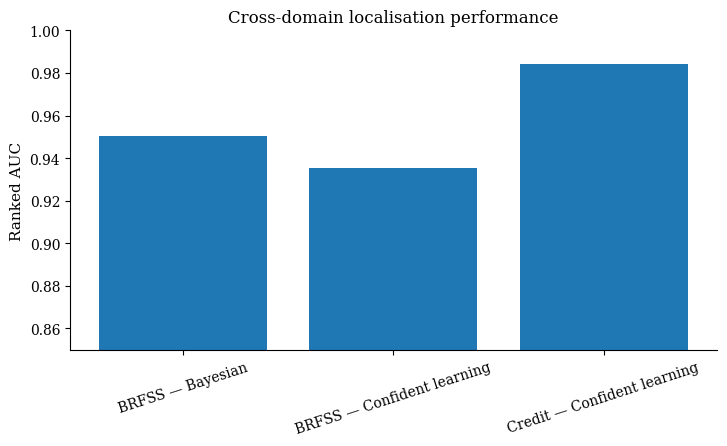

In [38]:
# Pull the main application results together in one table.
summary_rows = []

summary_rows.append({
    "domain": "BRFSS",
    "n_bayes": len(yb_bayes_obs),
    "region_share": region_b_bayes.mean(),
    "n_corrupted": int(flips_b.sum()),
    "effective_flip_rate": flips_b.mean(),
    "bayes_ranked_auc": bayes_metrics_b["ranked_auc"],
    "bayes_precision_at_k": bayes_metrics_b["precision_at_k"],
    "cl_ranked_auc": cl_metrics_b["ranked_auc"],
    "cl_precision_at_k": cl_metrics_b["precision_at_k"],
    "axis_fit_passed": diag_b_axis["converged"],
    "c_error_main": abs(
        c_draw.mean()
        - C_B_TRUE
    ),
    "q_error_main": abs(
        q_draw.mean()
        - Q_APPLIED
    ),
    "q_error_fixed_c": abs(
        q_fixed_c.mean()
        - Q_APPLIED
    ),
    "c_error_model_correct_y": abs(
        c_mc.mean()
        - C_B_TRUE
    ),
    "q_error_model_correct_y": abs(
        q_mc.mean()
        - Q_APPLIED
    ),
})

summary_rows.append({
    "domain": "Credit default",
    "n_bayes": len(yc_bayes_obs),
    "region_share": region_c_bayes.mean(),
    "n_corrupted": int(flips_c.sum()),
    "effective_flip_rate": flips_c.mean(),

    # Leave the Bayesian localisation fields empty because this fit failed.
    "bayes_ranked_auc": (
        bayes_metrics_c["ranked_auc"]
        if diag_c_axis["converged"]
        else np.nan
    ),
    "bayes_precision_at_k": (
        bayes_metrics_c["precision_at_k"]
        if diag_c_axis["converged"]
        else np.nan
    ),

    "cl_ranked_auc": cl_metrics_c["ranked_auc"],
    "cl_precision_at_k": cl_metrics_c["precision_at_k"],
    "axis_fit_passed": diag_c_axis["converged"],

    # Mechanism-recovery errors are not interpreted for the failed fit.
    "c_error_main": (
        abs(c_draw_c.mean() - C_C_TRUE)
        if diag_c_axis["converged"]
        else np.nan
    ),
    "q_error_main": (
        abs(q_draw_c.mean() - Q_APPLIED)
        if diag_c_axis["converged"]
        else np.nan
    ),
    "q_error_fixed_c": np.nan,
    "c_error_model_correct_y": np.nan,
    "q_error_model_correct_y": np.nan,
})

application_summary = pd.DataFrame(
    summary_rows
)

display(
    application_summary
)

application_summary.to_csv(
    RESULT_DIR / "highrep_chapter2_application_summary.csv",
    index=False
)


# Compare localisation results that are safe to interpret.
plot_rows = [
    {
        "domain_method": "BRFSS — Bayesian",
        "ranked_auc": bayes_metrics_b["ranked_auc"],
    },
    {
        "domain_method": "BRFSS — Confident learning",
        "ranked_auc": cl_metrics_b["ranked_auc"],
    },
    {
        "domain_method": "Credit — Confident learning",
        "ranked_auc": cl_metrics_c["ranked_auc"],
    },
]

# Only include Credit Bayesian results if the sampler checks pass.
if diag_c_axis["converged"]:
    plot_rows.append({
        "domain_method": "Credit — Bayesian",
        "ranked_auc": bayes_metrics_c["ranked_auc"],
    })

localisation_plot = pd.DataFrame(
    plot_rows
)


# Plot the cross-domain localisation comparison.
fig, ax = plt.subplots(
    figsize=(7.4, 4.6)
)

ax.bar(
    localisation_plot["domain_method"],
    localisation_plot["ranked_auc"],
)

ax.set_ylim(
    0.85,
    1.0
)

ax.set_ylabel(
    "Ranked AUC"
)

ax.set_title(
    "Cross-domain localisation performance"
)

ax.tick_params(
    axis="x",
    rotation=18
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_cross_domain_localisation_valid_fits.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "fig_ch2_cross_domain_localisation_valid_fits.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 5. Summary

The applied analyses show that localisation and mechanism recovery can behave very differently. In BRFSS, the injected corruptions are ranked well despite poor recovery of \(c\) and \(q\). The specification diagnostics suggest that mismatch in the logistic response model contributes to this behaviour.

The Credit analysis gives a similar localisation pattern, but the Bayesian fit fails the sampler diagnostic checks and is therefore not interpreted. The confident-learning result remains valid because it does not depend on the MCMC fit.

Overall, the semi-synthetic experiments show that strong observation-level localisation does not by itself imply successful recovery of the underlying corruption mechanism.